<a href="https://colab.research.google.com/github/Aragor85/Voiture_autonome/blob/segmentation/Ferguen_Djamel_1_scripts_072025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 2. Chemin vers le dossier contenant tes images
import os

image_folder = '/content/drive/MyDrive/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/train/zurich'

# 3. Vérifier les fichiers du dossier
images = os.listdir(image_folder)
print(images[:5])

['zurich_000005_000019_gtFine_labelIds.png', 'zurich_000013_000019_gtFine_polygons.json', 'zurich_000060_000019_gtFine_instanceIds.png', 'zurich_000104_000019_gtFine_polygons.json', 'zurich_000069_000019_gtFine_polygons.json']


(np.float64(-0.5), np.float64(2047.5), np.float64(1023.5), np.float64(-0.5))

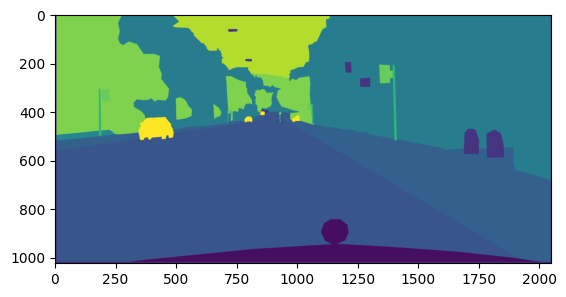

In [5]:
img_path = os.path.join(image_folder, images[110])
img = Image.open(img_path)

plt.imshow(img)
plt.axis('on')

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

### les chemins d'accés

In [20]:
image_path = '/content/drive/MyDrive/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/zurich/zurich_000000_000019_leftImg8bit.png'
mask_path  = '/content/drive/MyDrive/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/train/zurich/zurich_000000_000019_gtFine_color.png'

In [7]:
img = Image.open(image_path).convert("RGB")         # Image couleur
mask = Image.open(mask_path)                        # Image en niveaux de gris (Label IDs)

In [ ]:
mask_np = np.array(mask)

NameError: name 'mask_np' is not defined

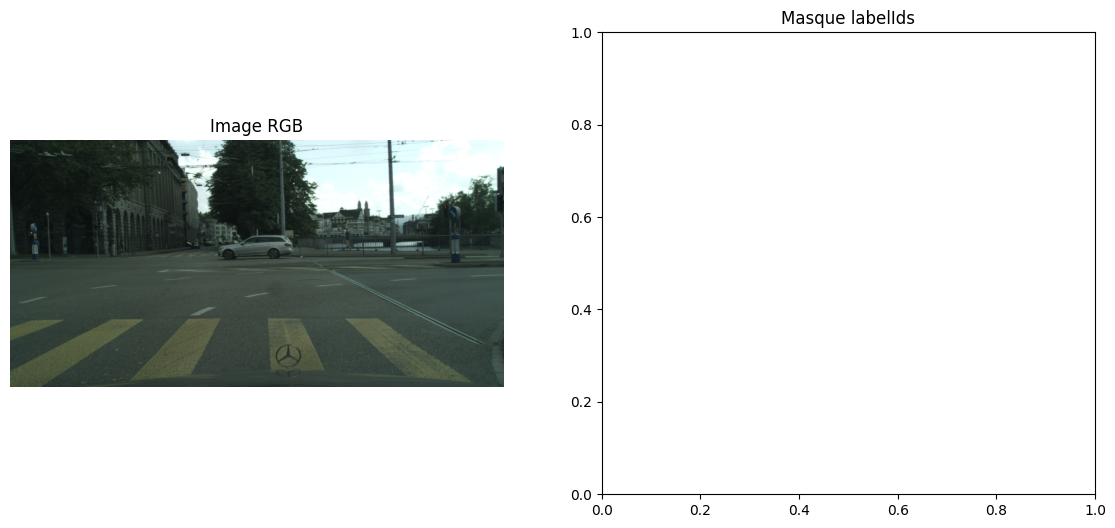

In [21]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Image RGB")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Masque labelIds")
plt.imshow(mask_np, cmap='nipy_spectral')  # Palette colorée pour bien visualiser
plt.axis('off')

plt.tight_layout()
plt.show()


## Définition des classes et mapping pour la segmentation


In [22]:
import numpy as np

# Dictionnaire de regroupement (noms uniquement pour info)
class_groups = {
    'flat': ['road', 'sidewalk', 'parking', 'rail track'],
    'human': ['person', 'rider'],
    'vehicle': ['car', 'truck', 'bus', 'on rails', 'motorcycle', 'bicycle', 'caravan', 'trailer'],
    'construction': ['building', 'wall', 'fence', 'guard rail', 'bridge', 'tunnel'],
    'object': ['pole', 'pole group', 'traffic sign', 'traffic light'],
    'nature': ['vegetation', 'terrain'],
    'sky': ['sky'],
    'void': ['unlabeled', 'ego vehicle', 'rectification border', 'out of roi', 'static', 'dynamic', 'ground']
}

# Mapping ID Cityscapes (0 à 33) → ID de groupe (0 à 7)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,  # void
    7: 0, 8: 0, 9: 0, 10: 0,                  # flat
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,  # construction
    17: 4, 18: 4, 19: 4, 20: 4,                # object
    21: 5, 22: 5,                              # nature
    23: 6,                                     # sky
    24: 1, 25: 1,                              # human
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2  # vehicle
}

# Tableau de conversion rapide (masques numpy)
id_to_group = np.zeros(256, dtype=np.uint8)
for id, group_id in cityscapes_mapping.items():
    id_to_group[id] = group_id

# Palette de couleurs pour affichage
group_colors = np.array([
    [128, 64, 128],  # flat
    [220, 20, 60],   # human
    [0, 0, 142],     # vehicle
    [70, 70, 70],    # construction
    [220, 220, 0],   # object
    [107, 142, 35],  # nature
    [70, 130, 180],  # sky
    [0, 0, 0]        # void
], dtype=np.uint8)

group_names = ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']
num_classes = len(group_names)



## Préparation des données


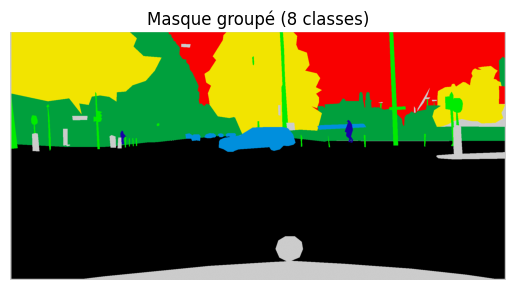

In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Chemin vers ton masque Cityscapes
mask_path = "/content/drive/MyDrive/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/train/zurich/zurich_000000_000019_gtFine_labelIds.png"

# Lecture du masque
mask = np.array(Image.open(mask_path))

# Mapping vers les groupes (supposons que id_to_group est déjà défini)
mask_grouped = id_to_group[mask]  # passe de 34 classes → 8 classes

# Affichage
plt.imshow(mask_grouped, cmap='nipy_spectral')
plt.title("Masque groupé (8 classes)")
plt.axis('off')
plt.show()


In [26]:
def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size, augment=False):
    # 🔧 Forcer le type string
    image_paths = list(map(str, image_paths))
    mask_paths = list(map(str, mask_paths))

    path_dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    def load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        flat_mask = tf.reshape(mask, [-1])
        mapped_mask = tf.gather(id_to_group_tf, flat_mask)
        mask = tf.reshape(mapped_mask, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)

        return img, mask

    dataset = path_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_data(image, mask):
            mask = tf.expand_dims(mask, axis=-1)

            # ⚡ Flip horizontal
            if tf.random.uniform(()) > 0.5:
                image = tf.image.flip_left_right(image)
                mask = tf.image.flip_left_right(mask)

            # ⚡ Contraste
            image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

            # ⚡ Luminosité
            image = tf.image.random_brightness(image, max_delta=0.1)

            # ⚡ Rotation 90° / 180° / 270°
            k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
            image = tf.image.rot90(image, k)
            mask = tf.image.rot90(mask, k)

            # ⚡ Zoom aléatoire (recadrage)
            def random_crop_zoom(image, mask, zoom_factor=0.9):
                img_shape = tf.shape(image)
                crop_h = tf.cast(tf.cast(img_shape[0], tf.float32) * zoom_factor, tf.int32)
                crop_w = tf.cast(tf.cast(img_shape[1], tf.float32) * zoom_factor, tf.int32)

                combined = tf.concat([image, tf.cast(mask, tf.float32)], axis=-1)
                cropped = tf.image.random_crop(combined, size=[crop_h, crop_w, 4])
                resized = tf.image.resize(cropped, size=[img_shape[0], img_shape[1]])

                return resized[..., :3], tf.cast(resized[..., 3:], tf.int32)

            if tf.random.uniform(()) > 0.5:
                image, mask = random_crop_zoom(image, mask, zoom_factor=0.9)

            image = tf.clip_by_value(image, 0.0, 1.0)
            mask = tf.squeeze(mask, axis=-1)

            return image, mask

        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


In [14]:
import numpy as np
import tensorflow as tf

# Définir le mapping numpy (déjà fait normalement)
id_to_group = np.zeros(256, dtype=np.uint8)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    7: 0, 8: 0, 9: 0, 10: 0,
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    17: 4, 18: 4, 19: 4, 20: 4,
    21: 5, 22: 5,
    23: 6,
    24: 1, 25: 1,
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2
}

for cid, gid in cityscapes_mapping.items():
    id_to_group[cid] = gid

# ✅ Convertir en TensorFlow constant
id_to_group_tf = tf.constant(id_to_group, dtype=tf.int32)


In [28]:
def create_dataset_cityscapes(
    leftImg8bit_dir,
    gtFine_dir,
    split='train',
    batch_size=8,
    img_size=(224,224),
    augment=False
):
    import os, tensorflow as tf

    image_paths, mask_paths = [], []

    # Dossiers cityscapes
    img_root  = os.path.join(leftImg8bit_dir, split)
    mask_root = os.path.join(gtFine_dir, split)

    for city in os.listdir(img_root):
        img_city_dir  = os.path.join(img_root, city)
        mask_city_dir = os.path.join(mask_root, city)
        if not os.path.isdir(mask_city_dir):
            continue

        for fname in os.listdir(img_city_dir):
            if fname.endswith("_leftImg8bit.png"):
                img_p = os.path.join(img_city_dir, fname)
                mask_name = fname.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
                mask_p   = os.path.join(mask_city_dir, mask_name)
                if os.path.exists(mask_p):
                    image_paths.append(str(img_p))
                    mask_paths.append(str(mask_p))

    print(f"{split.upper()} ➤ {len(image_paths)} images trouvées")

    # Création du tf.data.Dataset
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    def _load(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        # mapping id_to_group_tf doit exister
        flat = tf.reshape(mask, [-1])
        mapped = tf.gather(id_to_group_tf, flat)
        mask = tf.reshape(mapped, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)
        return img, mask

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def _aug(i,m):
            m = tf.expand_dims(m, -1)
            if tf.random.uniform(()) > .5:
                i = tf.image.flip_left_right(i)
                m = tf.image.flip_left_right(m)
            i = tf.clip_by_value(tf.image.random_brightness(i,0.1),0,1)
            m = tf.squeeze(m,-1)
            return i, m
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [29]:
left_root = "/content/drive/MyDrive/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit"
mask_root = "/content/drive/MyDrive/data/P8_Cityscapes_gtFine_trainvaltest/gtFine"
batch_size = 8
img_size = (224, 224)

train_dataset = create_dataset_cityscapes(
    leftImg8bit_dir=left_root,
    gtFine_dir=mask_root,
    split='train',
    batch_size=batch_size,
    img_size=img_size,
    augment=True
)

val_dataset = create_dataset_cityscapes(
    leftImg8bit_dir=left_root,
    gtFine_dir=mask_root,
    split='val',
    batch_size=batch_size,
    img_size=img_size,
    augment=False
)


TRAIN ➤ 2975 images trouvées
VAL ➤ 500 images trouvées


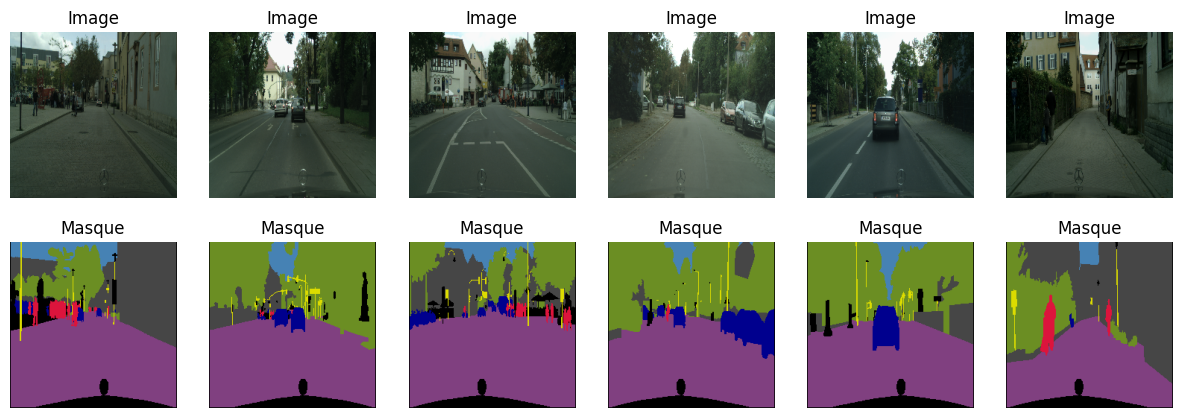

In [ ]:
def display_sample_batch(dataset, group_colors, num_images=6):
    import matplotlib.pyplot as plt
    for images, masks in dataset.take(1):
        plt.figure(figsize=(15, 5))
        for i in range(num_images):
            img = images[i].numpy()
            mask = masks[i].numpy()
            mask_rgb = group_colors[mask]
            plt.subplot(2, num_images, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title("Image")
            plt.subplot(2, num_images, i + 1 + num_images)
            plt.imshow(mask_rgb)
            plt.axis("off")
            plt.title("Masque")
        plt.show()

display_sample_batch(train_dataset, group_colors)


## Le modèle U-Net Mini

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 🔧 1. Construire U-Net mini
def build_unet_mini(input_shape=(224, 224, 3), num_classes=8):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    # Output layer
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c4)

    model = models.Model(inputs, outputs)
    return model



In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")

from losses_and_metrics import total_loss, dice_metric, mean_iou
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Construire le modèle
model = build_unet_mini(input_shape=(224, 224, 3), num_classes=8)

# 2. Compiler avec les métriques personnalisées
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss,
    metrics=['accuracy',dice_metric, mean_iou]
)

# 3. Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

model_checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/segmentation_project/experiments/exp_001_unet/models/best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 4. Entraînement
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3528 - dice_metric: 0.2338 - loss: 2.5746 - mean_iou: 0.1000
Epoch 1: val_loss improved from inf to 1.80555, saving model to /content/drive/MyDrive/segmentation_project/experiments/exp_001_unet/models/best_model.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 971s 5s/step - accuracy: 0.3536 - dice_metric: 0.2344 - loss: 2.5726 - mean_iou: 0.1001 - val_accuracy: 0.5742 - val_dice_metric: 0.4645 - val_loss: 1.8056 - val_mean_iou: 0.2264
Epoch 2/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.5903 - dice_metric: 0.4778 - loss: 1.7356 - mean_iou: 0.2416
Epoch 2: val_loss improved from 1.80555 to 1.61569, saving model to /content/drive/MyDrive/segmentation_project/experiments/exp_001_unet/models/best_model.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.5904 - dice_metric: 0.4780 - loss: 1.7352 - mean_iou: 0.2417 - val_accuracy: 0.6307 - val_dice_metric: 0.5443 - val_loss: 1.6157 - val_mean_iou: 0.2975
Epoch 3/25


In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/losses_and_metrics.py

'/content/drive/MyDrive/Colab Notebooks/losses_and_metrics.py'


### afficher les courbes loss / accuracy

> Ajouter une citation



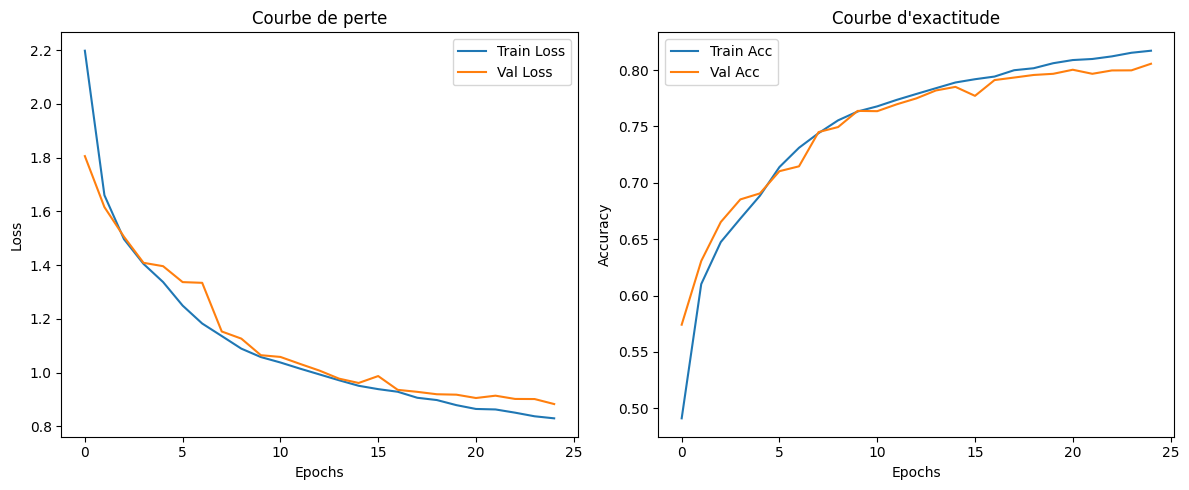

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    """
    Affiche les courbes loss et accuracy d’un entraînement Keras
    """
    # 📈 Courbe de perte
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Courbe de perte")
    plt.legend()

    # 📊 Courbe d’exactitude
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Courbe d'exactitude")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Appel après l'entraînement :
plot_training_curves(history)


### afficher des prédictions du modèle

> Ajouter une citation



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


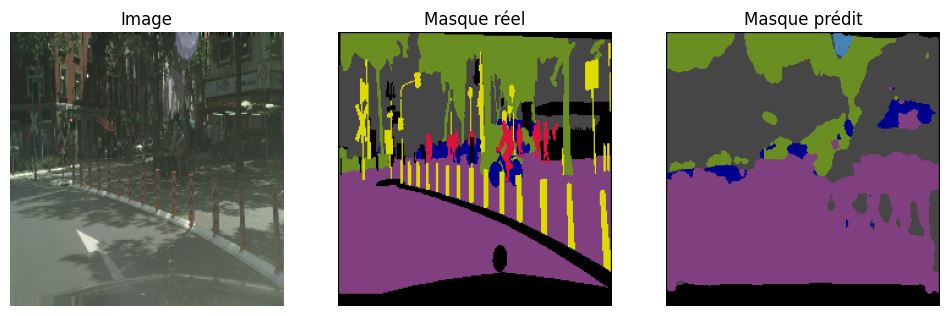

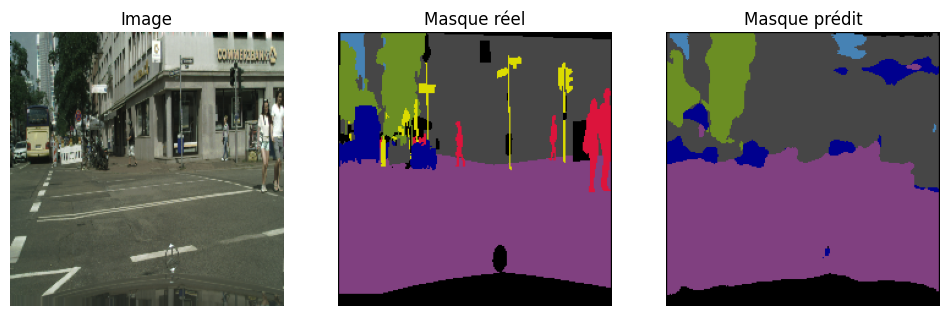

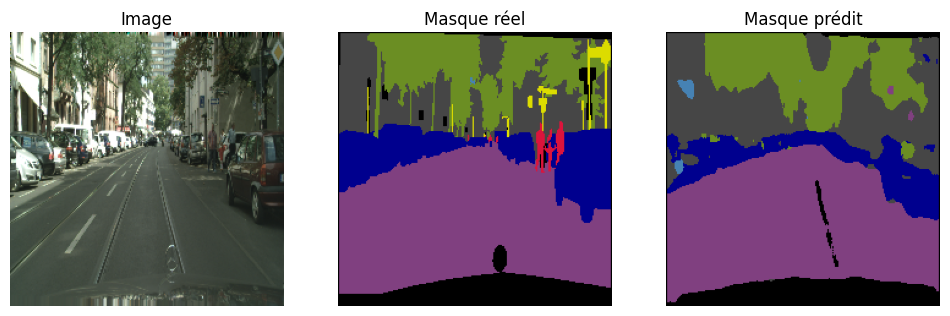

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, group_colors, n=3):
    """
    Affiche n exemples d’image + masque réel + prédiction
    """
    for i, (images, masks) in enumerate(dataset.take(n)):
        preds = model.predict(images)

        # Pour chaque image du batch
        for j in range(min(len(images), n)):
            img = images[j].numpy()
            true_mask = masks[j].numpy()
            pred_mask = np.argmax(preds[j], axis=-1)

            # Coloriser les masques avec ta palette
            true_colored = group_colors[true_mask]
            pred_colored = group_colors[pred_mask]

            # Affichage
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(true_colored)
            plt.title("Masque réel")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(pred_colored)
            plt.title("Masque prédit")
            plt.axis("off")

            plt.show()
        break  # Une seule itération (1 batch)

# Appel :
visualize_predictions(model, val_dataset, group_colors, n=3)


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### VGG16 classification V1

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import numpy as np


In [18]:
# Définir le mapping numpy (déjà fait normalement)
id_to_group = np.zeros(256, dtype=np.uint8)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    7: 0, 8: 0, 9: 0, 10: 0,
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    17: 4, 18: 4, 19: 4, 20: 4,
    21: 5, 22: 5,
    23: 6,
    24: 1, 25: 1,
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2
}

for cid, gid in cityscapes_mapping.items():
    id_to_group[cid] = gid

# ✅ Convertir en TensorFlow constant
id_to_group_tf = tf.constant(id_to_group, dtype=tf.int32)



In [19]:
def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size=(224, 224), augment=False):
    image_paths = list(map(str, image_paths))
    mask_paths = list(map(str, mask_paths))

    path_dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    def load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        flat = tf.reshape(mask, [-1])
        mapped = tf.gather(id_to_group_tf, flat)
        mask = tf.reshape(mapped, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)
        return img, mask

    dataset = path_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_data(img, mask):
            mask = tf.expand_dims(mask, axis=-1)
            if tf.random.uniform(()) > 0.5:
                img = tf.image.flip_left_right(img)
                mask = tf.image.flip_left_right(mask)
            mask = tf.squeeze(mask, axis=-1)
            return img, mask

        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [20]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = base_model.input

    s1 = base_model.get_layer("block1_conv2").output
    s2 = base_model.get_layer("block2_conv2").output
    s3 = base_model.get_layer("block3_conv3").output
    s4 = base_model.get_layer("block4_conv3").output
    b  = base_model.get_layer("block5_conv3").output  # Bottleneck

    # Decoder
    x = layers.Conv2DTranspose(512, 3, strides=2, padding="same")(b)
    x = layers.Concatenate()([x, s4])
    x = layers.Conv2D(512, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s3])
    x = layers.Conv2D(256, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s2])
    x = layers.Conv2D(128, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s1])
    x = layers.Conv2D(64, 3, activation='relu', padding="same")(x)


    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="VGG16_UNet")
    return model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from losses_and_metrics import dice_metric, mean_iou, total_loss

# 🔧 1. Créer le modèle VGG16 U-Net
model = build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8)

# ✅ 2. Compilation avec les métriques avancées
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=total_loss,
    metrics=['accuracy', dice_metric, mean_iou]
)

# 🔁 3. Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

model_ckpt = ModelCheckpoint(
    '/content/drive/MyDrive/unet_vgg16_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 🚀 4. Entraînement
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=[early_stop, model_ckpt]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6003 - dice_metric: 0.5182 - loss: 1.8176 - mean_iou: 0.3332   
Epoch 1: val_loss improved from inf to 0.92966, saving model to /content/drive/MyDrive/unet_vgg16_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.6010 - dice_metric: 0.5190 - loss: 1.8145 - mean_iou: 0.3335 - val_accuracy: 0.7978 - val_dice_metric: 0.7513 - val_loss: 0.9297 - val_mean_iou: 0.4835
Epoch 2/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8254 - dice_metric: 0.7718 - loss: 0.8129 - mean_iou: 0.5140
Epoch 2: val_loss improved from 0.92966 to 0.83128, saving model to /content/drive/MyDrive/unet_vgg16_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.8255 - dice_metric: 0.7718 - loss: 0.8126 - mean_iou: 0.5141 - val_accuracy: 0.8173 - val_dice_metric: 0.7720 - val_loss: 0.8313 - val_mean_iou: 0.5193
Epoch 3/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc

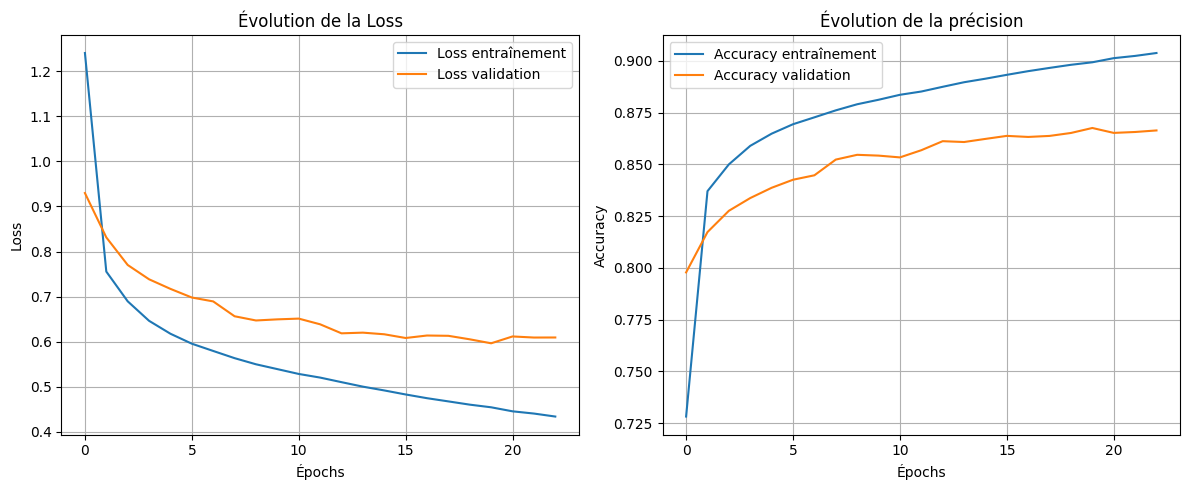

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Affiche les courbes de loss et accuracy pour un modèle Keras
    """
    plt.figure(figsize=(12, 5))

    # Courbe Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss entraînement')
    plt.plot(history.history['val_loss'], label='Loss validation')
    plt.xlabel('Épochs')
    plt.ylabel('Loss')
    plt.title('Évolution de la Loss')
    plt.legend()
    plt.grid(True)

    # Courbe Accuracy
    plt.subplot(1, 2, 2)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Accuracy entraînement')
        plt.plot(history.history['val_accuracy'], label='Accuracy validation')
        plt.ylabel('Accuracy')
        plt.title('Évolution de la précision')
    elif 'sparse_categorical_accuracy' in history.history:
        plt.plot(history.history['sparse_categorical_accuracy'], label='Accuracy entraînement')
        plt.plot(history.history['val_sparse_categorical_accuracy'], label='Accuracy validation')
        plt.ylabel('Sparse Categorical Accuracy')
        plt.title('Évolution de la précision')

    plt.xlabel('Épochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel à part (en dehors de la fonction)
plot_training_history(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


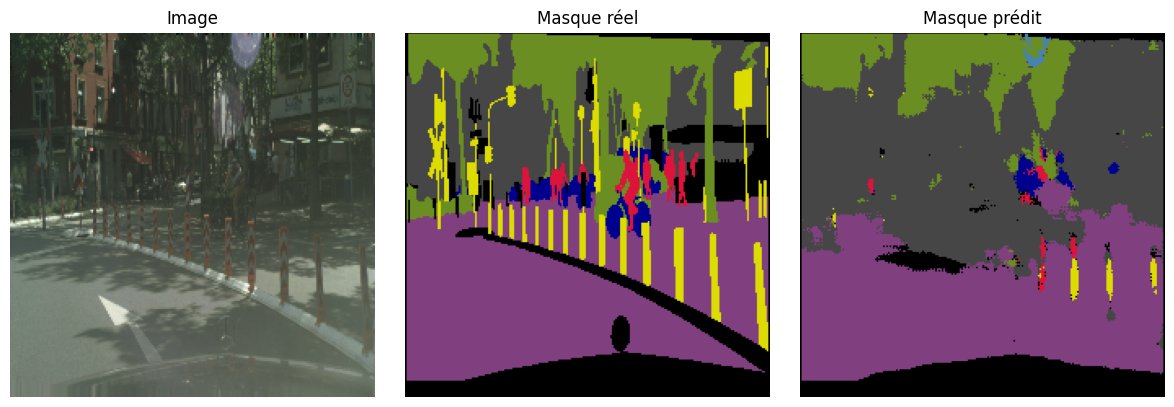

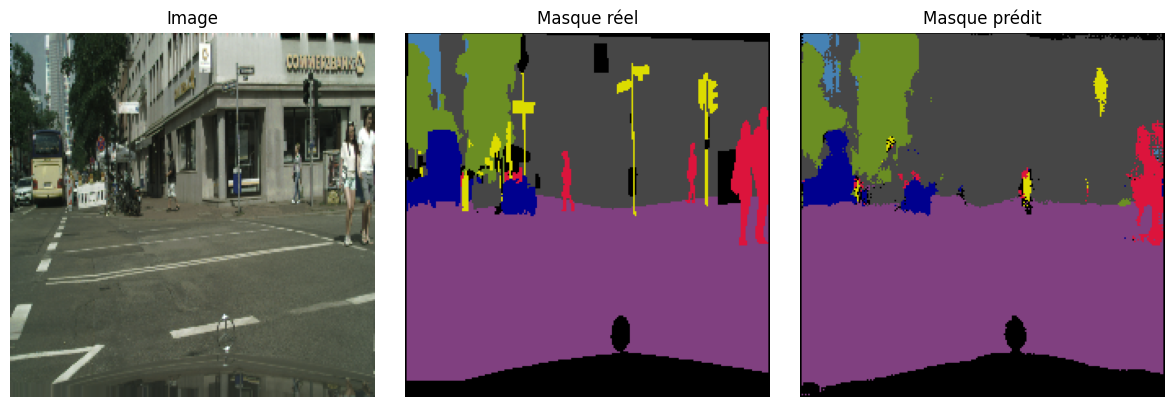

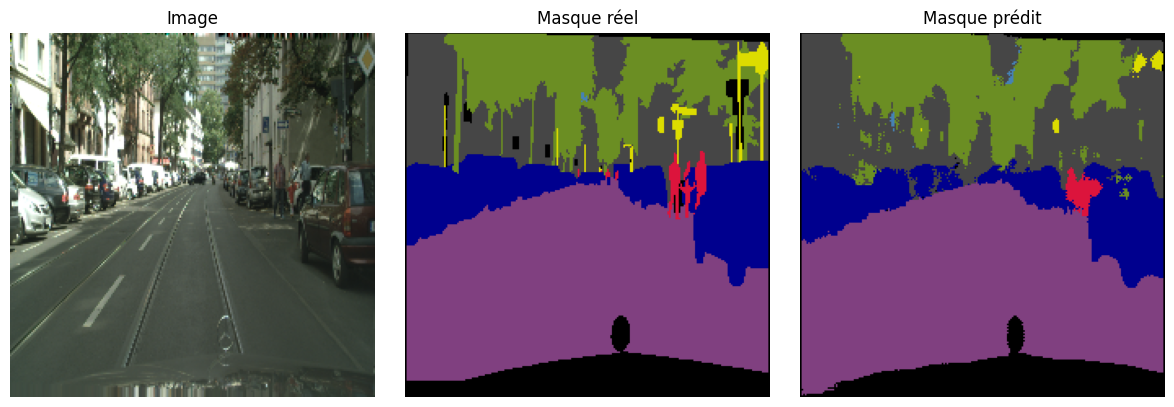

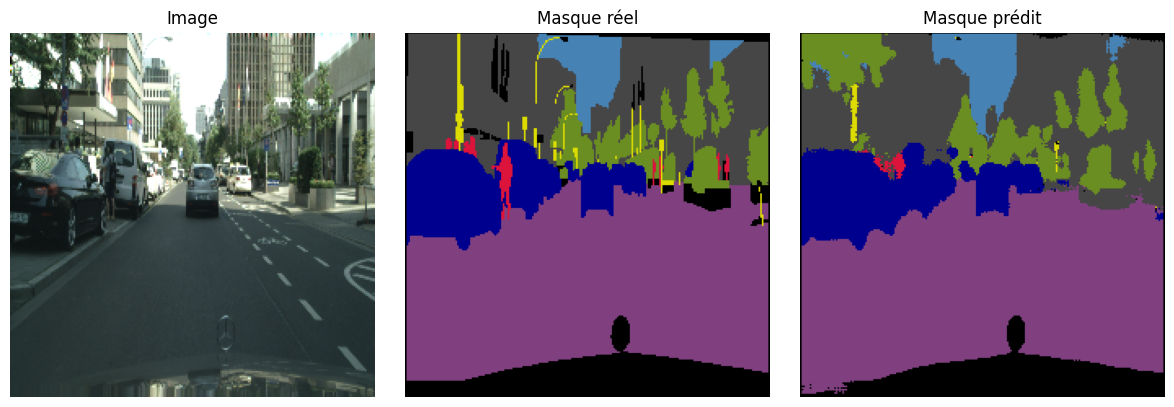

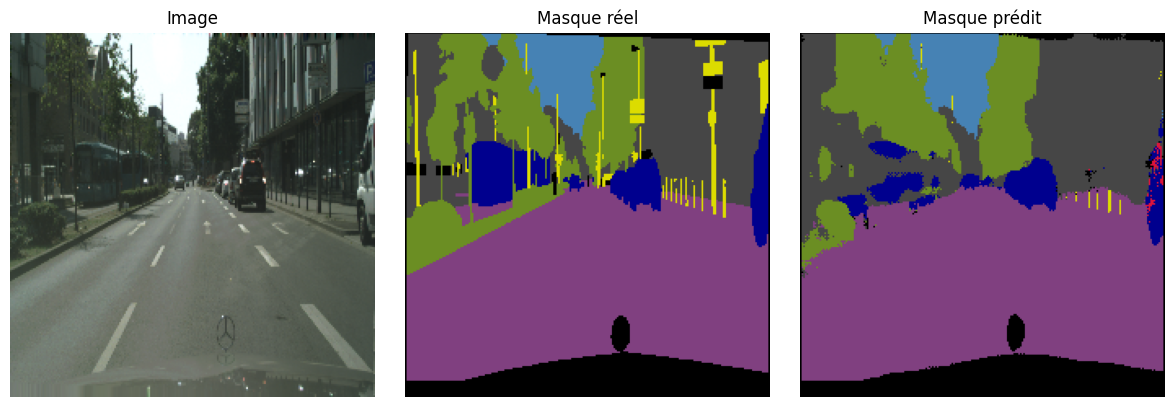

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions(model, dataset, id_to_color, num_samples=3):
    """
    Affiche quelques prédictions du modèle U-Net sur un dataset

    Args:
        model: modèle entraîné (ex: VGG16-UNet)
        dataset: un dataset tf.data contenant (image, mask)
        id_to_color: tableau (num_classes, 3) pour la couleur par classe
        num_samples: nombre d'exemples à afficher
    """
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = tf.argmax(preds, axis=-1).numpy()       # (batch, H, W)

        for i in range(num_samples):
            image = images[i].numpy()
            true_mask = masks[i].numpy()
            pred_mask = preds[i]

            # Colorisation
            true_mask_rgb = id_to_color[true_mask]
            pred_mask_rgb = id_to_color[pred_mask]

            # Affichage
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title("Masque réel")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title("Masque prédit")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions(model, val_dataset, group_colors, num_samples=5)

In [ ]:
for images, labels in train_dataset.take(1):
    print(images.shape, images.dtype)
    print(labels.shape, labels.dtype)


(16, 224, 224, 3) <dtype: 'float32'>
(16, 224, 224) <dtype: 'int32'>


In [ ]:
!ls -l losses_and_metrics.py

-rw-r--r-- 1 root root 1193 Jul 10 14:21 losses_and_metrics.py


In [ ]:
import numpy as np

# Nombre de classes (à adapter à ton dataset, ex: 8 pour toi)
num_classes = 8

# Initialisation du compteur
class_counts = np.zeros(num_classes)
total_pixels = 0

# Parcourir tout le dataset d'entraînement
for batch in train_dataset:
    # batch[1] contient les masques
    masks = batch[1].numpy()

    # Comptage des pixels pour chaque classe
    for class_id in range(num_classes):
        class_counts[class_id] += np.sum(masks == class_id)

    total_pixels += np.prod(masks.shape)

# Pourcentage de chaque classe
class_percentages = (class_counts / total_pixels) * 100

# Affichage
for class_id, pct in enumerate(class_percentages):
    print(f"Classe {class_id} : {pct:.2f}% des pixels")


Classe 0 : 38.71% des pixels
Classe 1 : 1.20% des pixels
Classe 2 : 7.31% des pixels
Classe 3 : 21.84% des pixels
Classe 4 : 1.77% des pixels
Classe 5 : 15.08% des pixels
Classe 6 : 3.55% des pixels
Classe 7 : 10.53% des pixels


### VGG16 classification_V2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import numpy as np


In [ ]:
# Définir le mapping numpy (déjà fait normalement)
id_to_group = np.zeros(256, dtype=np.uint8)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    7: 0, 8: 0, 9: 0, 10: 0,
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    17: 4, 18: 4, 19: 4, 20: 4,
    21: 5, 22: 5,
    23: 6,
    24: 1, 25: 1,
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2
}

for cid, gid in cityscapes_mapping.items():
    id_to_group[cid] = gid

# ✅ Convertir en TensorFlow constant
id_to_group_tf = tf.constant(id_to_group, dtype=tf.int32)



In [21]:
def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size=(224, 224), augment=False):
    image_paths = list(map(str, image_paths))
    mask_paths = list(map(str, mask_paths))

    path_dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    def load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        flat = tf.reshape(mask, [-1])
        mapped = tf.gather(id_to_group_tf, flat)
        mask = tf.reshape(mapped, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)
        return img, mask

    dataset = path_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_data(img, mask):
            mask = tf.expand_dims(mask, axis=-1)
            if tf.random.uniform(()) > 0.5:
                img = tf.image.flip_left_right(img)
                mask = tf.image.flip_left_right(mask)
            mask = tf.squeeze(mask, axis=-1)
            return img, mask

        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = base_model.input

    s1 = base_model.get_layer("block1_conv2").output
    s2 = base_model.get_layer("block2_conv2").output
    s3 = base_model.get_layer("block3_conv3").output
    s4 = base_model.get_layer("block4_conv3").output
    b  = base_model.get_layer("block5_conv3").output  # Bottleneck

    # Decoder
    x = layers.Conv2DTranspose(512, 3, strides=2, padding="same")(b)
    x = layers.Concatenate()([x, s4])
    x = layers.Conv2D(512, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s3])
    x = layers.Conv2D(256, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s2])
    x = layers.Conv2D(128, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s1])
    x = layers.Conv2D(64, 3, activation='relu', padding="same")(x)


    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="VGG16_UNet")
    return model


In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/losses_and_metrics.py

'/content/drive/MyDrive/Colab Notebooks/losses_and_metrics.py'


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from losses_and_metrics import (
    dice_metric,
    dice_loss_metric,
    cross_entropy_metric,
    total_loss
)
import tensorflow as tf

# 🔧 1. Construire le modèle avec ta fonction définie ailleurs
model = build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8)

# 🔓 2. Débloquer les couches profondes (fine-tuning possible sur block5)
for layer in model.layers:
    if "block5" in layer.name:
        layer.trainable = True

# ✅ 3. Compilation avec un learning rate fixe
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=total_loss,
    metrics=[
        'accuracy',
        dice_metric,
        dice_loss_metric,
        cross_entropy_metric
    ]
)

# 🔁 4. Callbacks : early stopping, réduction de LR, checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model_ckpt = ModelCheckpoint(
    '/content/drive/MyDrive/unet_vgg16_best_V2.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 🚀 5. Entraînement
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=[early_stop, reduce_lr, model_ckpt]
)


Epoch 1/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.7048 - cross_entropy_metric: 0.9964 - dice_loss_metric: 0.3717 - dice_metric: 0.6283 - loss: 1.3681
Epoch 1: val_loss improved from inf to 0.79400, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 249s 641ms/step - accuracy: 0.7050 - cross_entropy_metric: 0.9955 - dice_loss_metric: 0.3714 - dice_metric: 0.6286 - loss: 1.3669 - val_accuracy: 0.8286 - val_cross_entropy_metric: 0.5896 - val_dice_loss_metric: 0.2053 - val_dice_metric: 0.7947 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 2/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.8528 - cross_entropy_metric: 0.4865 - dice_loss_metric: 0.1935 - dice_metric: 0.8065 - loss: 0.6800
Epoch 2: val_loss improved from 0.79400 to 0.72520, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 237s 635ms/step - accuracy: 0.8528 - cross_entropy_metric: 0.4864 - dice_loss_metric: 0.1935 - dice_metric: 0.8065 - loss: 0.6799 - val_accuracy: 0.8416 - val_cross_entropy_metric: 0.5338 - val_dice_loss_metric: 0.1924 - val_dice_metric: 0.8076 - val_loss: 0.7252 - learning_rate: 1.0000e-04
Epoch 3/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8671 - cross_entropy_metric: 0.4349 - dice_loss_metric: 0.1747 - dice_metric: 0.8253 - loss: 0.6096
Epoch 3: val_loss improved from 0.72520 to 0.67309, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 251s 675ms/step - accuracy: 0.8671 - cross_entropy_metric: 0.4349 - dice_loss_metric: 0.1747 - dice_metric: 0.8253 - loss: 0.6096 - val_accuracy: 0.8521 - val_cross_entropy_metric: 0.4923 - val_dice_loss_metric: 0.1818 - val_dice_metric: 0.8182 - val_loss: 0.6731 - learning_rate: 1.0000e-04
Epoch 4/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8755 - cross_entropy_metric: 0.4045 - dice_loss_metric: 0.1637 - dice_metric: 0.8363 - loss: 0.5683
Epoch 4: val_loss improved from 0.67309 to 0.65758, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 242s 650ms/step - accuracy: 0.8755 - cross_entropy_metric: 0.4045 - dice_loss_metric: 0.1637 - dice_metric: 0.8363 - loss: 0.5682 - val_accuracy: 0.8550 - val_cross_entropy_metric: 0.4805 - val_dice_loss_metric: 0.1781 - val_dice_metric: 0.8219 - val_loss: 0.6576 - learning_rate: 1.0000e-04
Epoch 5/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8811 - cross_entropy_metric: 0.3850 - dice_loss_metric: 0.1564 - dice_metric: 0.8436 - loss: 0.5414
Epoch 5: val_loss improved from 0.65758 to 0.62675, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


...

372/372 ━━━━━━━━━━━━━━━━━━━━ 243s 652ms/step - accuracy: 0.8859 - cross_entropy_metric: 0.3645 - dice_loss_metric: 0.1497 - dice_metric: 0.8503 - loss: 0.5142 - val_accuracy: 0.8628 - val_cross_entropy_metric: 0.4550 - val_dice_loss_metric: 0.1708 - val_dice_metric: 0.8292 - val_loss: 0.6246 - learning_rate: 1.0000e-04
Epoch 7/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.8914 - cross_entropy_metric: 0.3450 - dice_loss_metric: 0.1426 - dice_metric: 0.8574 - loss: 0.4875
Epoch 7: val_loss improved from 0.62463 to 0.60467, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 245s 658ms/step - accuracy: 0.8914 - cross_entropy_metric: 0.3449 - dice_loss_metric: 0.1425 - dice_metric: 0.8575 - loss: 0.4875 - val_accuracy: 0.8660 - val_cross_entropy_metric: 0.4380 - val_dice_loss_metric: 0.1679 - val_dice_metric: 0.8321 - val_loss: 0.6047 - learning_rate: 1.0000e-04
Epoch 8/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8959 - cross_entropy_metric: 0.3295 - dice_loss_metric: 0.1366 - dice_metric: 0.8634 - loss: 0.4661
Epoch 8: val_loss improved from 0.60467 to 0.59919, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 240s 645ms/step - accuracy: 0.8959 - cross_entropy_metric: 0.3295 - dice_loss_metric: 0.1366 - dice_metric: 0.8634 - loss: 0.4661 - val_accuracy: 0.8670 - val_cross_entropy_metric: 0.4319 - val_dice_loss_metric: 0.1686 - val_dice_metric: 0.8314 - val_loss: 0.5992 - learning_rate: 1.0000e-04
Epoch 9/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9000 - cross_entropy_metric: 0.3157 - dice_loss_metric: 0.1312 - dice_metric: 0.8688 - loss: 0.4469
Epoch 9: val_loss improved from 0.59919 to 0.59601, saving model to /content/drive/MyDrive/unet_vgg16_best_V2.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 241s 647ms/step - accuracy: 0.9000 - cross_entropy_metric: 0.3157 - dice_loss_metric: 0.1312 - dice_metric: 0.8688 - loss: 0.4469 - val_accuracy: 0.8681 - val_cross_entropy_metric: 0.4334 - val_dice_loss_metric: 0.1638 - val_dice_metric: 0.8362 - val_loss: 0.5960 - learning_rate: 1.0000e-04
Epoch 10/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9047 - cross_entropy_metric: 0.2991 - dice_loss_metric: 0.1249 - dice_metric: 0.8751 - loss: 0.4241
Epoch 10: val_loss did not improve from 0.59601
372/372 ━━━━━━━━━━━━━━━━━━━━ 251s 619ms/step - accuracy: 0.9047 - cross_entropy_metric: 0.2991 - dice_loss_metric: 0.1249 - dice_metric: 0.8751 - loss: 0.4240 - val_accuracy: 0.8659 - val_cross_entropy_metric: 0.4466 - val_dice_loss_metric: 0.1680 - val_dice_metric: 0.8320 - val_loss: 0.6135 - learning_rate: 1.0000e-04
Epoch 11/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9067 - cross_entropy_metric: 0.2931 - dice_loss_metric: 0.1222 - dice_me

372/372 ━━━━━━━━━━━━━━━━━━━━ 245s 658ms/step - accuracy: 0.9169 - cross_entropy_metric: 0.2561 - dice_loss_metric: 0.1093 - dice_metric: 0.8907 - loss: 0.3654 - val_accuracy: 0.8797 - val_cross_entropy_metric: 0.4080 - val_dice_loss_metric: 0.1469 - val_dice_metric: 0.8531 - val_loss: 0.5538 - learning_rate: 2.5000e-05
Epoch 15/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.9220 - cross_entropy_metric: 0.2397 - dice_loss_metric: 0.1029 - dice_metric: 0.8971 - loss: 0.3427
Epoch 15: val_loss did not improve from 0.55378
372/372 ━━━━━━━━━━━━━━━━━━━━ 238s 639ms/step - accuracy: 0.9220 - cross_entropy_metric: 0.2397 - dice_loss_metric: 0.1029 - dice_metric: 0.8971 - loss: 0.3427 - val_accuracy: 0.8786 - val_cross_entropy_metric: 0.4179 - val_dice_loss_metric: 0.1474 - val_dice_metric: 0.8526 - val_loss: 0.5641 - learning_rate: 2.5000e-05
Epoch 16/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.9241 - cross_entropy_metric: 0.2338 - dice_loss_metric: 0.1002 - dice_me

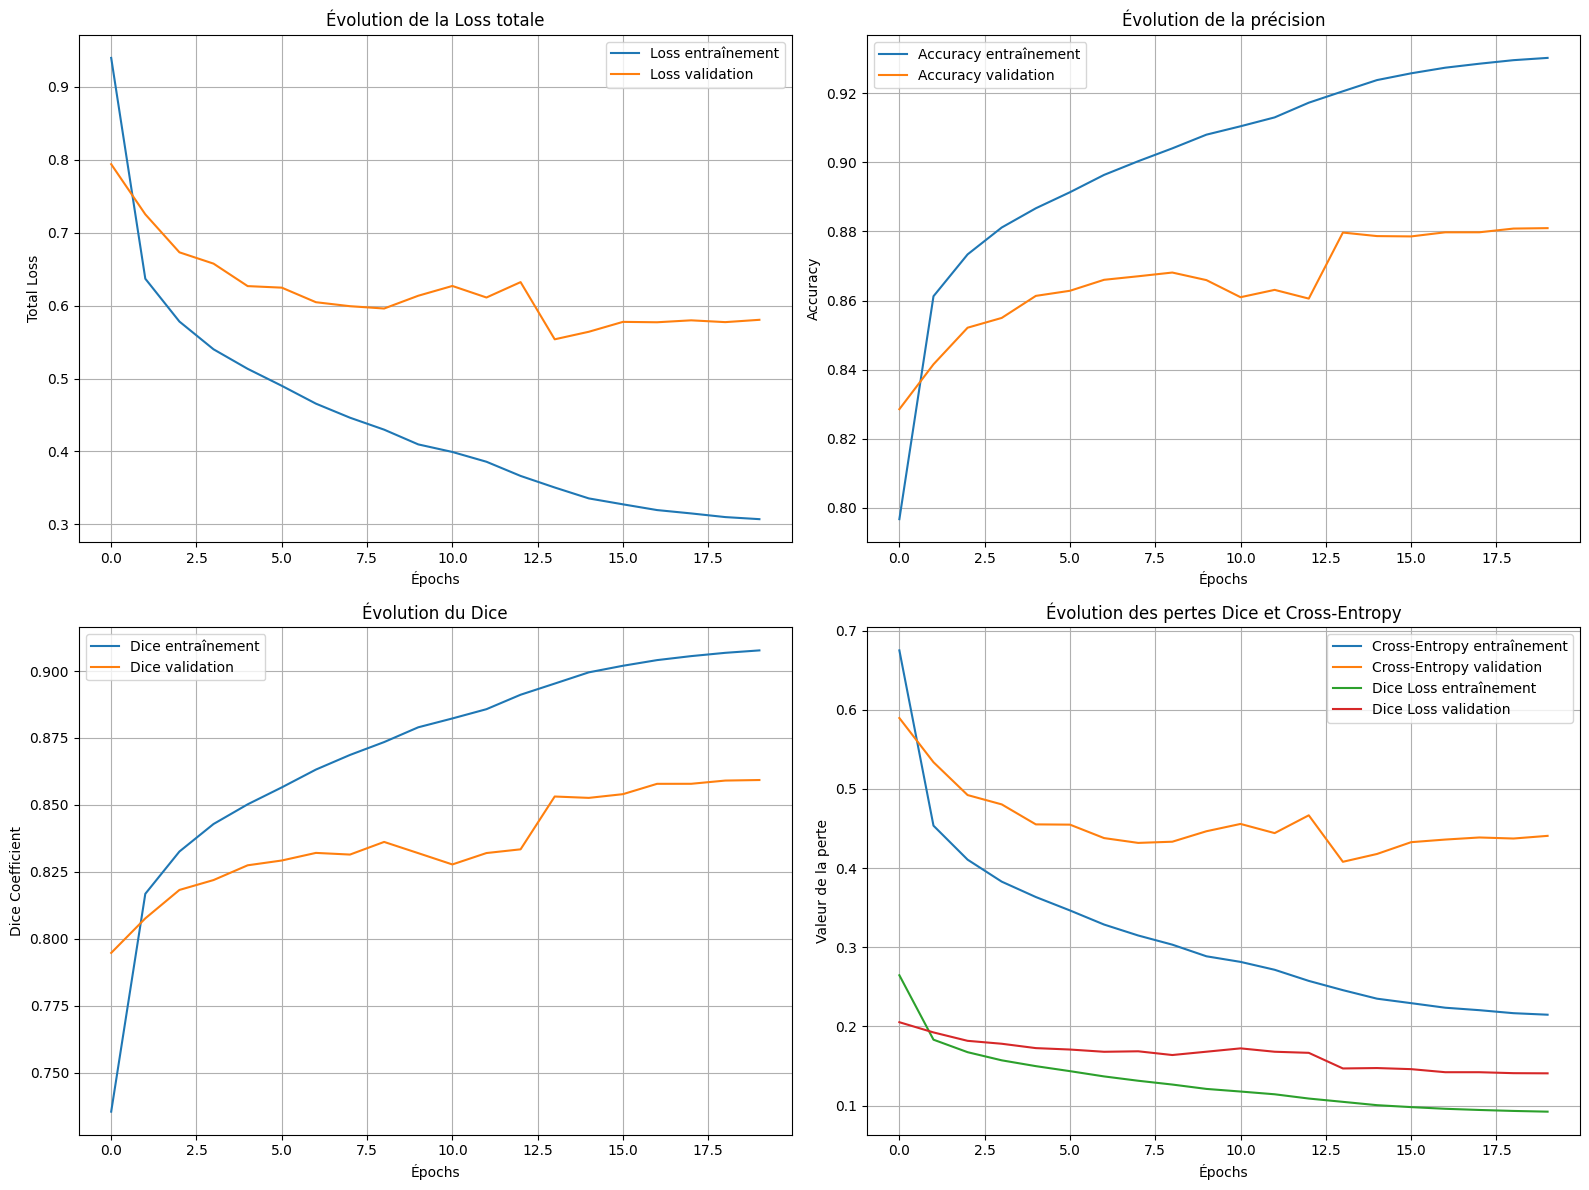

In [ ]:
import matplotlib.pyplot as plt

def plot_full_training_history(history):
    """
    Affiche les courbes complètes de loss, accuracy, dice, cross_entropy et dice_loss
    """
    metrics = history.history.keys()
    plt.figure(figsize=(16, 12))

    # 1. Total Loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Loss entraînement')
    plt.plot(history.history['val_loss'], label='Loss validation')
    plt.xlabel('Épochs')
    plt.ylabel('Total Loss')
    plt.title('Évolution de la Loss totale')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy
    plt.subplot(2, 2, 2)
    if 'accuracy' in metrics:
        plt.plot(history.history['accuracy'], label='Accuracy entraînement')
        plt.plot(history.history['val_accuracy'], label='Accuracy validation')
        plt.ylabel('Accuracy')
        plt.title('Évolution de la précision')
        plt.xlabel('Épochs')
        plt.legend()
        plt.grid(True)

    # 3. Dice Score
    if 'dice_metric' in metrics:
        plt.subplot(2, 2, 3)
        plt.plot(history.history['dice_metric'], label='Dice entraînement')
        plt.plot(history.history['val_dice_metric'], label='Dice validation')
        plt.xlabel('Épochs')
        plt.ylabel('Dice Coefficient')
        plt.title('Évolution du Dice')
        plt.legend()
        plt.grid(True)

    # 4. Cross-Entropy et Dice Loss
    if 'cross_entropy_metric' in metrics and 'dice_loss_metric' in metrics:
        plt.subplot(2, 2, 4)
        plt.plot(history.history['cross_entropy_metric'], label='Cross-Entropy entraînement')
        plt.plot(history.history['val_cross_entropy_metric'], label='Cross-Entropy validation')
        plt.plot(history.history['dice_loss_metric'], label='Dice Loss entraînement')
        plt.plot(history.history['val_dice_loss_metric'], label='Dice Loss validation')
        plt.xlabel('Épochs')
        plt.ylabel('Valeur de la perte')
        plt.title('Évolution des pertes Dice et Cross-Entropy')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_full_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


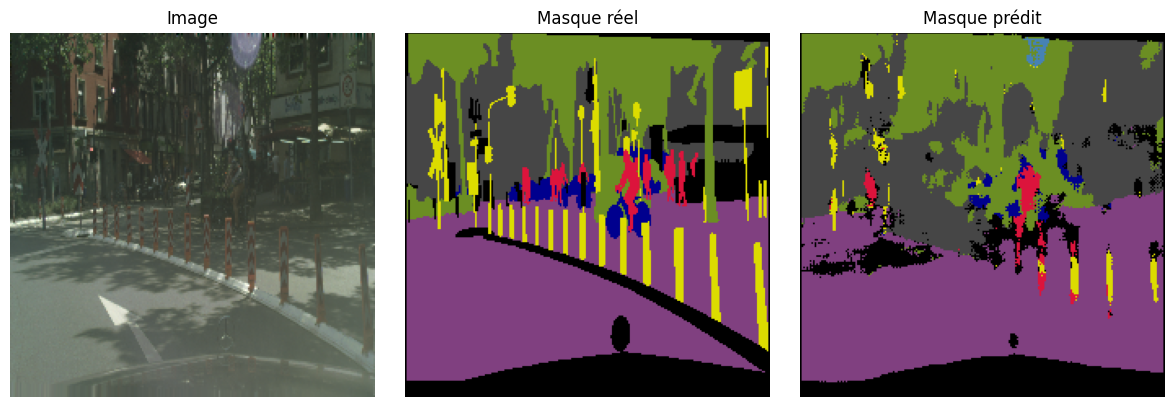

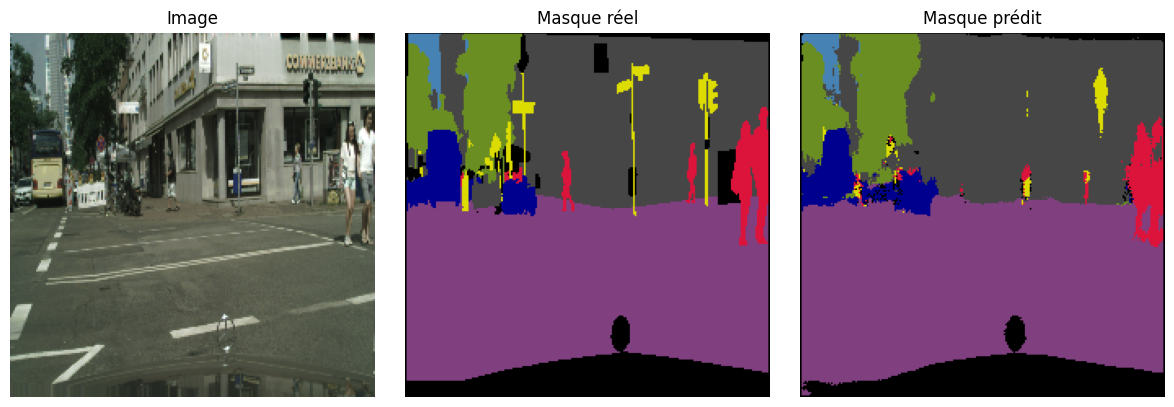

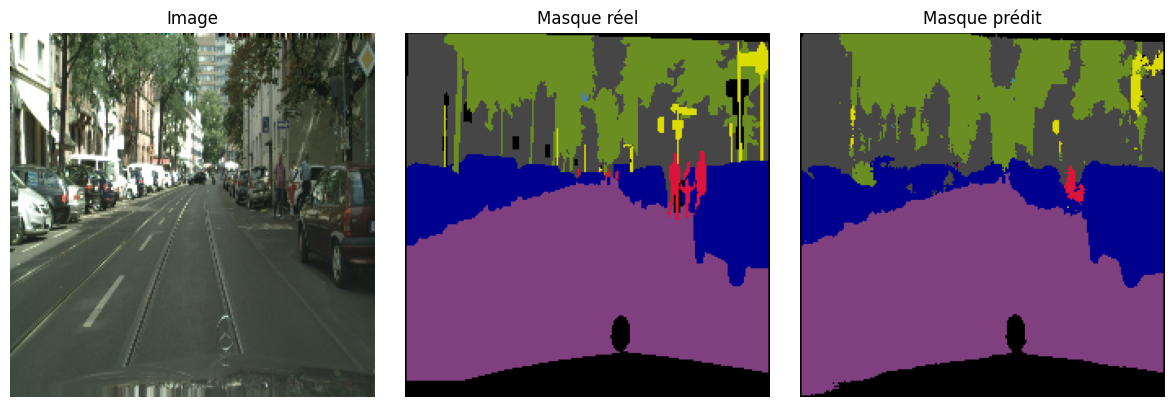

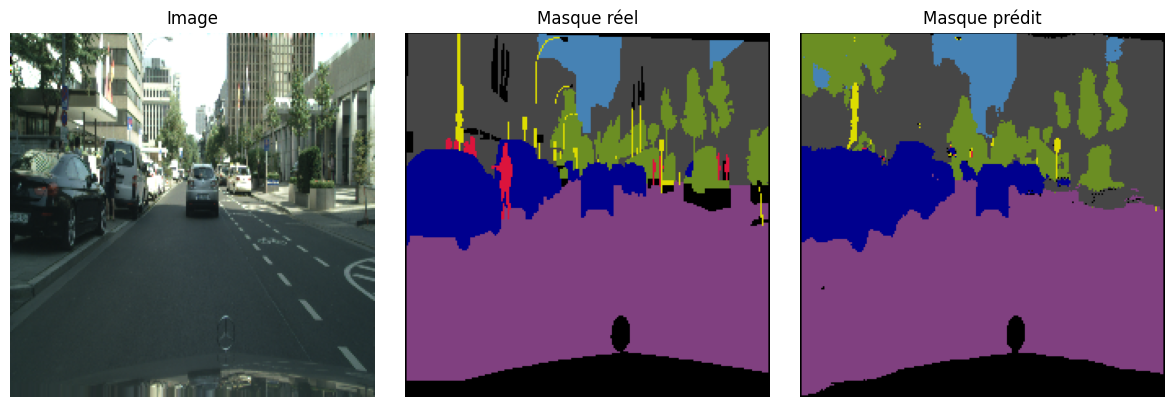

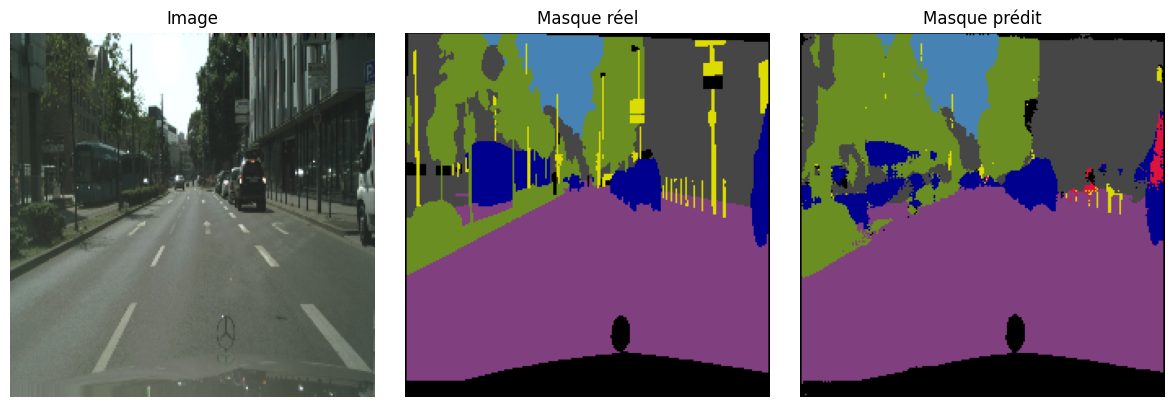

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions(model, dataset, id_to_color, num_samples=3):
    """
    Affiche quelques prédictions du modèle U-Net sur un dataset

    Args:
        model: modèle entraîné (ex: VGG16-UNet)
        dataset: un dataset tf.data contenant (image, mask)
        id_to_color: tableau (num_classes, 3) pour la couleur par classe
        num_samples: nombre d'exemples à afficher
    """
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = tf.argmax(preds, axis=-1).numpy()       # (batch, H, W)

        for i in range(num_samples):
            image = images[i].numpy()
            true_mask = masks[i].numpy()
            pred_mask = preds[i]

            # Colorisation
            true_mask_rgb = id_to_color[true_mask]
            pred_mask_rgb = id_to_color[pred_mask]

            # Affichage
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title("Masque réel")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title("Masque prédit")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions(model, val_dataset, group_colors, num_samples=5)

####  matrice IoU par classe

In [15]:
import sys
sys.path.append("/content/drive/MyDrive/")  # Pour accéder aux fichiers personnalisés

In [30]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from losses_and_metrics import (
    dice_metric,
    dice_loss_metric,
    cross_entropy_metric,
    total_loss
)
import tensorflow as tf

# 🔁 Classes Cityscapes groupées (0 à 7)
num_classes = 8
class_names = [
    "Flat", "Human", "Vehicle", "Construction",
    "Object", "Nature", "Sky", "Void"
]

# 🔧 Charger le modèle .h5 avec les métriques custom
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/unet_vgg16_best_V2.h5",
    custom_objects={
        "dice_metric": dice_metric,
        "dice_loss_metric": dice_loss_metric,
        "cross_entropy_metric": cross_entropy_metric,
        "total_loss": total_loss
    }
)

# 🧮 Initialiser les compteurs IoU
TP = np.zeros(num_classes, dtype=np.int64)
FP = np.zeros(num_classes, dtype=np.int64)
FN = np.zeros(num_classes, dtype=np.int64)

# 🔁 Prédictions sur tout val_dataset
for images, true_masks in val_dataset:
    preds = model.predict(images)
    pred_masks = tf.argmax(preds, axis=-1)  # shape: (B, H, W)

    for true_mask, pred_mask in zip(true_masks, pred_masks):
        true_flat = tf.reshape(true_mask, [-1]).numpy()
        pred_flat = tf.reshape(pred_mask, [-1]).numpy()

        for c in range(num_classes):
            TP[c] += np.sum((true_flat == c) & (pred_flat == c))
            FP[c] += np.sum((true_flat != c) & (pred_flat == c))
            FN[c] += np.sum((true_flat == c) & (pred_flat != c))

# 📊 Calcul IoU
IoU_per_class = TP / (TP + FP + FN + 1e-6)

# 🔢 Affichage
print("📊 Intersection over Union (IoU) par classe :\n")
for i, name in enumerate(class_names):
    print(f"Classe {i} ({name}): IoU = {IoU_per_class[i]*100:.2f}%")

# 📈 Moyenne globale
mean_iou = np.mean(IoU_per_class)
print(f"\n🔹 IoU Moyenne (mIoU): {mean_iou*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━

In [14]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from losses_and_metrics import dice_metric, total_loss, mean_iou

# 📁 Paramètres
MODEL_PATH = "/content/drive/MyDrive/unet_vgg16_best_V2.h5"
NUM_CLASSES = 8
CLASS_NAMES = [
    "Flat", "Human", "Vehicle", "Construction",
    "Object", "Nature", "Sky", "Void"
]

# 📦 Chargement du modèle
model = load_model(
    MODEL_PATH,
    custom_objects={
        "dice_metric": dice_metric,
        "total_loss": total_loss,
        "mean_iou": mean_iou
    }
)

# 📊 Initialisation du compteur global
total_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

# 🔁 Parcourir les images de validation
for x_batch, _ in val_dataset:
    y_pred = model.predict(x_batch)
    y_pred_labels = np.argmax(y_pred, axis=-1)  # (batch_size, H, W)

    for pred_mask in y_pred_labels:
        class_counts = np.bincount(pred_mask.flatten(), minlength=NUM_CLASSES)
        total_counts += class_counts

# ✅ Affichage des résultats
total_pixels = np.sum(total_counts)
print("🎯 Distribution des classes détectées :\n")
for class_id, count in enumerate(total_counts):
    percentage = (count / total_pixels) * 100
    print(f"Classe {class_id:1d} - {CLASS_NAMES[class_id]:<13}: {count:8d} pixels ({percentage:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━

### Modélisation sans data augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import numpy as np


In [ ]:
# Définir le mapping numpy (déjà fait normalement)
id_to_group = np.zeros(256, dtype=np.uint8)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    7: 0, 8: 0, 9: 0, 10: 0,
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    17: 4, 18: 4, 19: 4, 20: 4,
    21: 5, 22: 5,
    23: 6,
    24: 1, 25: 1,
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2
}

for cid, gid in cityscapes_mapping.items():
    id_to_group[cid] = gid

# ✅ Convertir en TensorFlow constant
id_to_group_tf = tf.constant(id_to_group, dtype=tf.int32)



In [ ]:
import tensorflow as tf

def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size=(224, 224)):
    """
    Crée un tf.data.Dataset pour la segmentation, sans data augmentation.

    Args:
      image_paths (list[str] ou tf.Tensor): chemins vers les images.
      mask_paths  (list[str] ou tf.Tensor): chemins vers les masques.
      batch_size  (int): taille des batchs.
      img_size    (tuple): taille de redimensionnement (hauteur, largeur).

    Returns:
      tf.data.Dataset yielding (image, mask) pairs, batchés et pré‑chargés.
    """
    # Assurer que ce sont des strings
    image_paths = list(map(str, image_paths))
    mask_paths  = list(map(str, mask_paths))

    # 1) Dataset de chemins
    path_ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    # 2) Fonction de chargement + pré‑traitement
    def _load_and_preprocess(img_path, mask_path):
        # Image
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        # Masque
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)  # indices de classes

        # Regroupement d’IDs en vos 8 catégories
        flat   = tf.reshape(mask, [-1])
        mapped = tf.gather(id_to_group_tf, flat)
        mask   = tf.reshape(mapped, tf.shape(mask))
        mask   = tf.squeeze(mask, axis=-1)

        return img, mask

    # 3) Appliquer la fonction en parallèle
    ds = path_ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # 4) Batch & pré‑chargement
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [27]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ✅ Chemins racine vers images et masques
base_img_dir = r"/content/drive/MyDrive/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit"
base_mask_dir = r"/content/drive/MyDrive/data/P8_Cityscapes_gtFine_trainvaltest/gtFine"

# ✅ Récupération des chemins
def get_paths(split):
    image_paths = glob.glob(os.path.join(base_img_dir, split, "*", "*_leftImg8bit.png"))
    mask_paths = [img_path.replace(base_img_dir, base_mask_dir).replace("leftImg8bit", "gtFine_labelIds") for img_path in image_paths]
    return image_paths, mask_paths

train_imgs, train_masks = get_paths("train")
val_imgs, val_masks     = get_paths("val")
test_imgs, test_masks   = get_paths("test")

print(f"Train: {len(train_imgs)} images")
print(f"Val:   {len(val_imgs)} images")
print(f"Test:  {len(test_imgs)} images")

# ✅ Mapping des 34 classes vers 8 groupes Cityscapes
id_to_group = {
    7: 0, 8: 0, 11: 1, 12: 1, 13: 1, 17: 2, 19: 2, 20: 2, 21: 2, 22: 2,
    23: 3, 24: 3, 25: 3, 26: 3, 27: 3, 28: 3,
    31: 4, 32: 4, 33: 4,
    3: 5, 4: 5, 2: 5,
    1: 6,
    0: 7, 10: 7, 18: 7, 29: 7, 30: 7, -1: 7
}
id_to_group_tf = tf.constant([id_to_group.get(i, 7) for i in range(34)], dtype=tf.int32)

# ✅ Fonction de dataset
def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size=(224, 224), augment=False):
    image_paths = list(map(str, image_paths))
    mask_paths = list(map(str, mask_paths))

    dataset = tf.data.Dataset.from_tensor_slices((
        tf.constant(image_paths, dtype=tf.string),
        tf.constant(mask_paths, dtype=tf.string)
    ))

    def _load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        flat = tf.reshape(mask, [-1])
        mapped = tf.gather(id_to_group_tf, flat)
        mask = tf.reshape(mapped, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)
        return img, mask

    dataset = dataset.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def _augment(img, mask):
            mask = tf.expand_dims(mask, axis=-1)
            if tf.random.uniform(()) > 0.5:
                img = tf.image.flip_left_right(img)
                mask = tf.image.flip_left_right(mask)
            mask = tf.squeeze(mask, axis=-1)
            return img, mask

        dataset = dataset.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ✅ Créer les datasets
train_ds = create_dataset_from_paths(train_imgs, train_masks, batch_size=16, augment=False)
val_ds   = create_dataset_from_paths(val_imgs, val_masks, batch_size=16, augment=False)

# ✅ Palette de couleurs
palette = [
    (128, 64, 128),   # Flat
    (220, 20, 60),    # Human
    (0, 0, 142),      # Vehicle
    (70, 70, 70),     # Construction
    (153, 153, 153),  # Object
    (107, 142, 35),   # Nature
    (70, 130, 180),   # Sky
    (0, 0, 0)         # Void
]

def colorize_mask(mask):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for i, color in enumerate(palette):
        color_mask[mask == i] = color
    return color_mask

# ✅ Affichage
def show_batch(dataset, n=3):
    for images, masks in dataset.take(1):
        plt.figure(figsize=(12, n * 4))
        for i in range(n):
            img = images[i].numpy()
            mask = masks[i].numpy()
            color_mask = colorize_mask(mask)

            plt.subplot(n, 2, 2*i + 1)
            plt.imshow(img)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(n, 2, 2*i + 2)
            plt.imshow(color_mask)
            plt.title("Masque (8 classes)")
            plt.axis("off")
        plt.tight_layout()
        plt.show()




Train: 2975 images
Val:   500 images
Test:  200 images


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = base_model.input

    s1 = base_model.get_layer("block1_conv2").output
    s2 = base_model.get_layer("block2_conv2").output
    s3 = base_model.get_layer("block3_conv3").output
    s4 = base_model.get_layer("block4_conv3").output
    b  = base_model.get_layer("block5_conv3").output  # Bottleneck

    # Decoder
    x = layers.Conv2DTranspose(512, 3, strides=2, padding="same")(b)
    x = layers.Concatenate()([x, s4])
    x = layers.Conv2D(512, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s3])
    x = layers.Conv2D(256, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s2])
    x = layers.Conv2D(128, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s1])
    x = layers.Conv2D(64, 3, activation='relu', padding="same")(x)


    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="VGG16_UNet")
    return model


In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/losses_and_metrics.py

'/content/drive/MyDrive/Colab Notebooks/losses_and_metrics.py'


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from losses_and_metrics import (
    dice_metric,
    dice_loss_metric,
    cross_entropy_metric,
    total_loss
)
import tensorflow as tf

# 🔧 1. Construire le modèle avec ta fonction définie ailleurs
model = build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8)

# 🔓 2. Débloquer les couches profondes (fine-tuning possible sur block5)
for layer in model.layers:
    if "block5" in layer.name:
        layer.trainable = True

# ✅ 3. Compilation avec un learning rate fixe
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=total_loss,
    metrics=[
        'accuracy',
        dice_metric,
        dice_loss_metric,
        cross_entropy_metric
    ]
)

# 🔁 4. Callbacks : early stopping, réduction de LR, checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model_ckpt = ModelCheckpoint(
    '/content/drive/MyDrive/unet_vgg16_best_V3.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 🚀 5. Entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[early_stop, reduce_lr, model_ckpt]
)


Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5594 - cross_entropy_metric: 1.4394 - dice_loss_metric: 0.5125 - dice_metric: 0.4875 - loss: 1.9519
Epoch 1: val_loss improved from inf to 0.91633, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 1599s 8s/step - accuracy: 0.5603 - cross_entropy_metric: 1.4366 - dice_loss_metric: 0.5117 - dice_metric: 0.4883 - loss: 1.9483 - val_accuracy: 0.7965 - val_cross_entropy_metric: 0.6634 - val_dice_loss_metric: 0.2558 - val_dice_metric: 0.7442 - val_loss: 0.9163 - learning_rate: 1.0000e-04
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8343 - cross_entropy_metric: 0.5472 - dice_loss_metric: 0.2217 - dice_metric: 0.7783 - loss: 0.7689
Epoch 2: val_loss improved from 0.91633 to 0.85762, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.8343 - cross_entropy_metric: 0.5471 - dice_loss_metric: 0.2216 - dice_metric: 0.7784 - loss: 0.7687 - val_accuracy: 0.8069 - val_cross_entropy_metric: 0.6205 - val_dice_loss_metric: 0.2401 - val_dice_metric: 0.7599 - val_loss: 0.8576 - learning_rate: 1.0000e-04
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8511 - cross_entropy_metric: 0.4876 - dice_loss_metric: 0.1989 - dice_metric: 0.8011 - loss: 0.6865
Epoch 3: val_loss improved from 0.85762 to 0.79948, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8511 - cross_entropy_metric: 0.4876 - dice_loss_metric: 0.1988 - dice_metric: 0.8012 - loss: 0.6864 - val_accuracy: 0.8223 - val_cross_entropy_metric: 0.5816 - val_dice_loss_metric: 0.2209 - val_dice_metric: 0.7791 - val_loss: 0.7995 - learning_rate: 1.0000e-04
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8608 - cross_entropy_metric: 0.4520 - dice_loss_metric: 0.1851 - dice_metric: 0.8149 - loss: 0.6372
Epoch 4: val_loss improved from 0.79948 to 0.74397, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.8608 - cross_entropy_metric: 0.4520 - dice_loss_metric: 0.1851 - dice_metric: 0.8149 - loss: 0.6371 - val_accuracy: 0.8386 - val_cross_entropy_metric: 0.5467 - val_dice_loss_metric: 0.2005 - val_dice_metric: 0.7995 - val_loss: 0.7440 - learning_rate: 1.0000e-04
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8691 - cross_entropy_metric: 0.4229 - dice_loss_metric: 0.1734 - dice_metric: 0.8266 - loss: 0.5963
Epoch 5: val_loss improved from 0.74397 to 0.71840, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8691 - cross_entropy_metric: 0.4228 - dice_loss_metric: 0.1734 - dice_metric: 0.8266 - loss: 0.5962 - val_accuracy: 0.8459 - val_cross_entropy_metric: 0.5310 - val_dice_loss_metric: 0.1907 - val_dice_metric: 0.8093 - val_loss: 0.7184 - learning_rate: 1.0000e-04
Epoch 6/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8757 - cross_entropy_metric: 0.3970 - dice_loss_metric: 0.1638 - dice_metric: 0.8362 - loss: 0.5608
Epoch 6: val_loss improved from 0.71840 to 0.70264, saving model to /content/drive/MyDrive/unet_vgg16_best_V3.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.8757 - cross_entropy_metric: 0.3969 - dice_loss_metric: 0.1638 - dice_metric: 0.8362 - loss: 0.5607 - val_accuracy: 0.8487 - val_cross_entropy_metric: 0.5200 - val_dice_loss_metric: 0.1860 - val_dice_metric: 0.8140 - val_loss: 0.7026 - learning_rate: 1.0000e-04
Epoch 7/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8819 - cross_entropy_metric: 0.3728 - dice_loss_metric: 0.1551 - dice_metric: 0.8449 - loss: 0.5279
Epoch 7: val_loss did not improve from 0.70264
186/186 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.8820 - cross_entropy_metric: 0.3728 - dice_loss_metric: 0.1550 - dice_metric: 0.8450 - loss: 0.5278 - val_accuracy: 0.8459 - val_cross_entropy_metric: 0.5295 - val_dice_loss_metric: 0.1882 - val_dice_metric: 0.8118 - val_loss: 0.7145 - learning_rate: 1.0000e-04
Epoch 8/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8863 - cross_entropy_metric: 0.3575 - dice_loss_metric: 0.1493 - dice_metric: 0.8507 - 

186/186 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.8863 - cross_entropy_metric: 0.3574 - dice_loss_metric: 0.1493 - dice_metric: 0.8507 - loss: 0.5067 - val_accuracy: 0.8556 - val_cross_entropy_metric: 0.5103 - val_dice_loss_metric: 0.1767 - val_dice_metric: 0.8233 - val_loss: 0.6838 - learning_rate: 1.0000e-04
Epoch 9/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8906 - cross_entropy_metric: 0.3429 - dice_loss_metric: 0.1434 - dice_metric: 0.8566 - loss: 0.4863
Epoch 9: val_loss did not improve from 0.68384
186/186 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8906 - cross_entropy_metric: 0.3429 - dice_loss_metric: 0.1434 - dice_metric: 0.8566 - loss: 0.4863 - val_accuracy: 0.8611 - val_cross_entropy_metric: 0.5268 - val_dice_loss_metric: 0.1681 - val_dice_metric: 0.8319 - val_loss: 0.6917 - learning_rate: 1.0000e-04
Epoch 10/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8962 - cross_entropy_metric: 0.3234 - dice_loss_metric: 0.1358 - dice_metric: 0.8642 -

186/186 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9027 - cross_entropy_metric: 0.3024 - dice_loss_metric: 0.1274 - dice_metric: 0.8726 - loss: 0.4298 - val_accuracy: 0.8693 - val_cross_entropy_metric: 0.4424 - val_dice_loss_metric: 0.1630 - val_dice_metric: 0.8370 - val_loss: 0.6027 - learning_rate: 5.0000e-05
Epoch 12/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9117 - cross_entropy_metric: 0.2732 - dice_loss_metric: 0.1162 - dice_metric: 0.8838 - loss: 0.3894
Epoch 12: val_loss did not improve from 0.60266
186/186 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.9117 - cross_entropy_metric: 0.2732 - dice_loss_metric: 0.1162 - dice_metric: 0.8838 - loss: 0.3894 - val_accuracy: 0.8695 - val_cross_entropy_metric: 0.4627 - val_dice_loss_metric: 0.1600 - val_dice_metric: 0.8400 - val_loss: 0.6200 - learning_rate: 5.0000e-05
Epoch 13/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9176 - cross_entropy_metric: 0.2549 - dice_loss_metric: 0.1086 - dice_metric: 0.8914

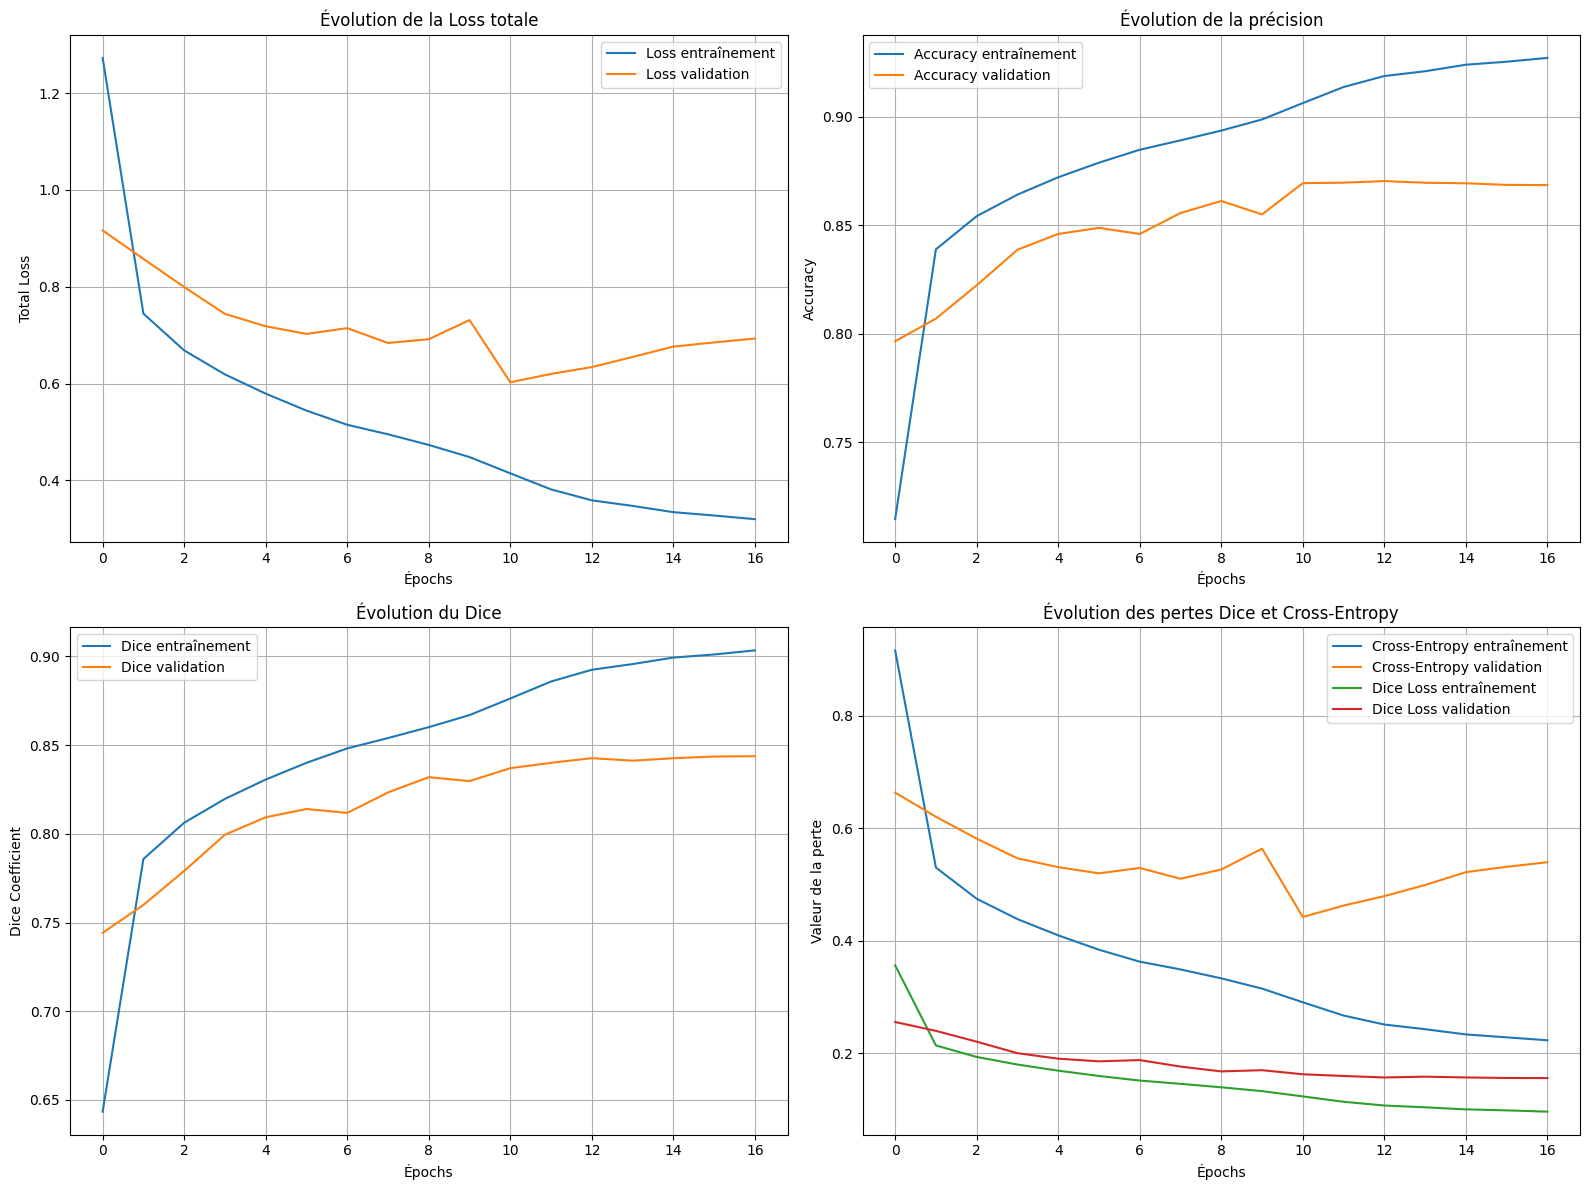

In [ ]:
import matplotlib.pyplot as plt

def plot_full_training_history(history):
    """
    Affiche les courbes complètes de loss, accuracy, dice, cross_entropy et dice_loss
    """
    metrics = history.history.keys()
    plt.figure(figsize=(16, 12))

    # 1. Total Loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Loss entraînement')
    plt.plot(history.history['val_loss'], label='Loss validation')
    plt.xlabel('Épochs')
    plt.ylabel('Total Loss')
    plt.title('Évolution de la Loss totale')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy
    plt.subplot(2, 2, 2)
    if 'accuracy' in metrics:
        plt.plot(history.history['accuracy'], label='Accuracy entraînement')
        plt.plot(history.history['val_accuracy'], label='Accuracy validation')
        plt.ylabel('Accuracy')
        plt.title('Évolution de la précision')
        plt.xlabel('Épochs')
        plt.legend()
        plt.grid(True)

    # 3. Dice Score
    if 'dice_metric' in metrics:
        plt.subplot(2, 2, 3)
        plt.plot(history.history['dice_metric'], label='Dice entraînement')
        plt.plot(history.history['val_dice_metric'], label='Dice validation')
        plt.xlabel('Épochs')
        plt.ylabel('Dice Coefficient')
        plt.title('Évolution du Dice')
        plt.legend()
        plt.grid(True)

    # 4. Cross-Entropy et Dice Loss
    if 'cross_entropy_metric' in metrics and 'dice_loss_metric' in metrics:
        plt.subplot(2, 2, 4)
        plt.plot(history.history['cross_entropy_metric'], label='Cross-Entropy entraînement')
        plt.plot(history.history['val_cross_entropy_metric'], label='Cross-Entropy validation')
        plt.plot(history.history['dice_loss_metric'], label='Dice Loss entraînement')
        plt.plot(history.history['val_dice_loss_metric'], label='Dice Loss validation')
        plt.xlabel('Épochs')
        plt.ylabel('Valeur de la perte')
        plt.title('Évolution des pertes Dice et Cross-Entropy')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_full_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


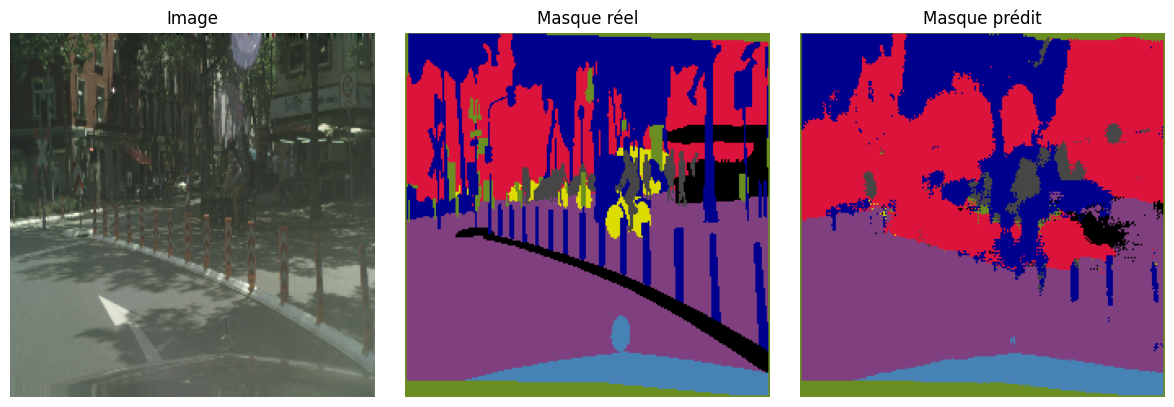

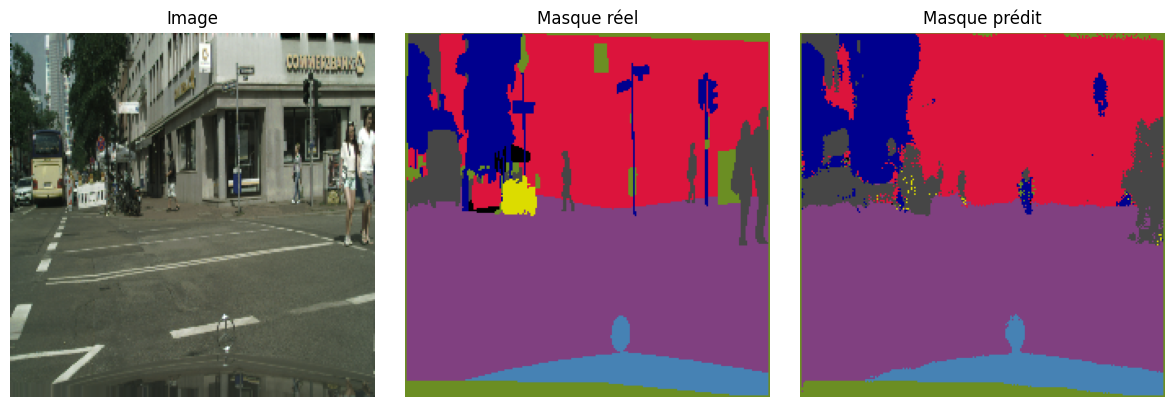

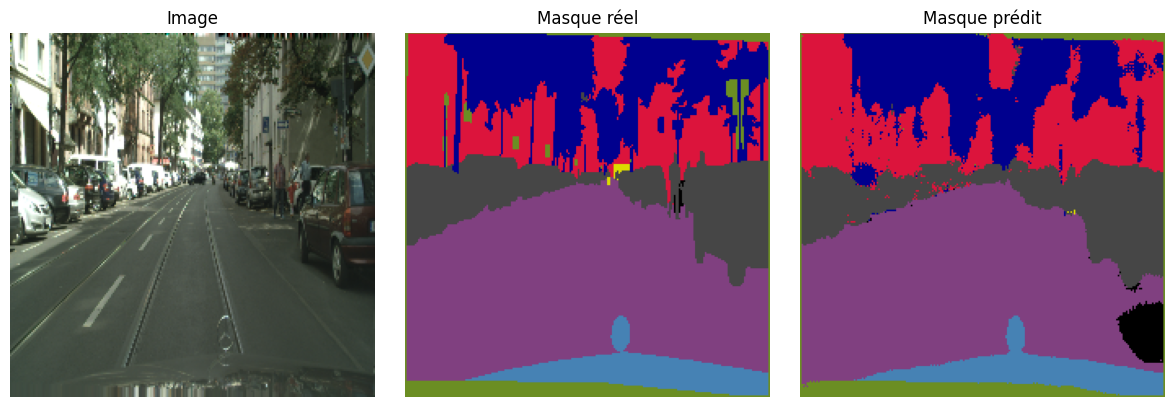

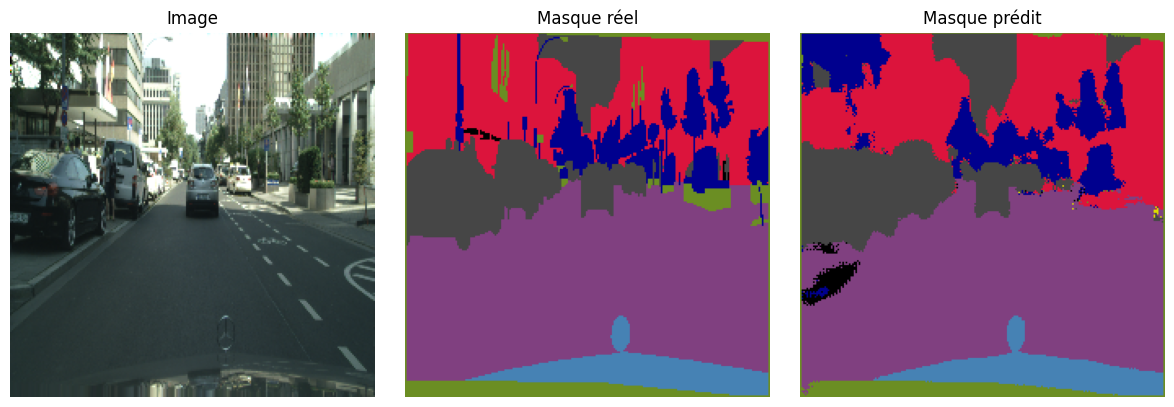

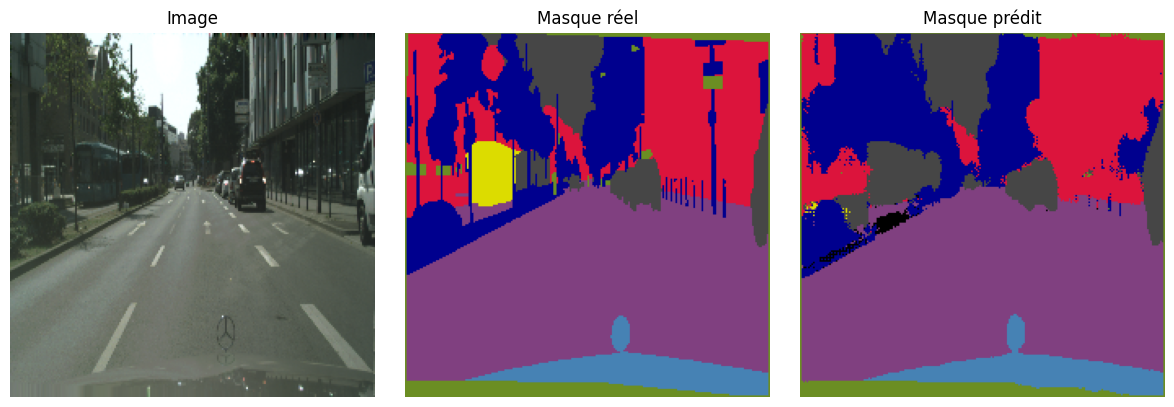

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions(model, dataset, id_to_color, num_samples=3):
    """
    Affiche quelques prédictions du modèle U-Net sur un dataset

    Args:
        model: modèle entraîné (ex: VGG16-UNet)
        dataset: un dataset tf.data contenant (image, mask)
        id_to_color: tableau (num_classes, 3) pour la couleur par classe
        num_samples: nombre d'exemples à afficher
    """
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = tf.argmax(preds, axis=-1).numpy()       # (batch, H, W)

        for i in range(num_samples):
            image = images[i].numpy()
            true_mask = masks[i].numpy()
            pred_mask = preds[i]

            # Colorisation
            true_mask_rgb = id_to_color[true_mask]
            pred_mask_rgb = id_to_color[pred_mask]

            # Affichage
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title("Masque réel")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title("Masque prédit")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions(model, val_ds, group_colors, num_samples=5)

In [6]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

In [8]:
import sys
sys.path.append("/content/drive/MyDrive/")  # Pour accéder aux fichiers personnalisés

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from losses_and_metrics import dice_metric, total_loss, mean_iou

# 📁 Paramètres
MODEL_PATH = "/content/drive/MyDrive/unet_vgg16_best_V2.h5"
NUM_CLASSES = 8
CLASS_NAMES = [
    "Flat", "Human", "Vehicle", "Construction",
    "Object", "Nature", "Sky", "Void"
]

# 📦 Chargement du modèle
model = load_model(
    MODEL_PATH,
    custom_objects={
        "dice_metric": dice_metric,
        "total_loss": total_loss,
        "mean_iou": mean_iou
    }
)

# 📊 Initialisation du compteur global
total_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

# 🔁 Parcourir les images de validation
for x_batch, _ in val_dataset:
    y_pred = model.predict(x_batch)
    y_pred_labels = np.argmax(y_pred, axis=-1)  # (batch_size, H, W)

    for pred_mask in y_pred_labels:
        class_counts = np.bincount(pred_mask.flatten(), minlength=NUM_CLASSES)
        total_counts += class_counts

# ✅ Affichage des résultats
total_pixels = np.sum(total_counts)
print("🎯 Distribution des classes détectées :\n")
for class_id, count in enumerate(total_counts):
    percentage = (count / total_pixels) * 100
    print(f"Classe {class_id:1d} - {CLASS_NAMES[class_id]:<13}: {count:8d} pixels ({percentage:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━

### Test avec data augmentation ++++

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import numpy as np


In [13]:
# Définir le mapping numpy (déjà fait normalement)
id_to_group = np.zeros(256, dtype=np.uint8)
cityscapes_mapping = {
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    7: 0, 8: 0, 9: 0, 10: 0,
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    17: 4, 18: 4, 19: 4, 20: 4,
    21: 5, 22: 5,
    23: 6,
    24: 1, 25: 1,
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2
}

for cid, gid in cityscapes_mapping.items():
    id_to_group[cid] = gid

# ✅ Convertir en TensorFlow constant
id_to_group_tf = tf.constant(id_to_group, dtype=tf.int32)



In [28]:
import tensorflow as tf

def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size, augment=False):
    image_paths = list(map(str, image_paths))
    mask_paths  = list(map(str, mask_paths))

    path_dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    def load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)

        flat_mask   = tf.reshape(mask, [-1])
        mapped_mask = tf.gather(id_to_group_tf, flat_mask)
        mask        = tf.reshape(mapped_mask, tf.shape(mask))
        mask        = tf.squeeze(mask, axis=-1)

        return img, mask

    dataset = path_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_data(image, mask):
            mask = tf.expand_dims(mask, axis=-1)

            # 1) Flip horizontal
            if tf.random.uniform(()) > 0.5:
                image = tf.image.flip_left_right(image)
                mask  = tf.image.flip_left_right(mask)

            # 2) Contraste & luminosité
            image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
            image = tf.image.random_brightness(image, max_delta=0.1)

            # 3) Saturation
            image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

            # 4) Rotation aléatoire (0, 90, 180, 270°)
            k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
            image = tf.image.rot90(image, k)
            mask  = tf.image.rot90(mask, k)

            # 5) Zoom (recadrage aléatoire)
            if tf.random.uniform(()) > 0.5:
                h, w = tf.shape(image)[0], tf.shape(image)[1]
                zoom_factor = 0.9
                ch = tf.cast(tf.cast(h, tf.float32) * zoom_factor, tf.int32)
                cw = tf.cast(tf.cast(w, tf.float32) * zoom_factor, tf.int32)
                combined = tf.concat([image, tf.cast(mask, tf.float32)], axis=-1)
                cropped = tf.image.random_crop(combined, size=[ch, cw, 4])
                resized = tf.image.resize(cropped, size=[h, w])
                image = resized[..., :3]
                mask = tf.cast(resized[..., 3:], tf.int32)

            # 6) Bruit gaussien
            noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
            image = image + noise

            image = tf.clip_by_value(image, 0.0, 1.0)
            mask  = tf.squeeze(mask, axis=-1)

            return image, mask

        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [29]:
# 📦 Paramètres
batch_size = 16
img_size = (224, 224)

# ✅ Avec augmentations pour l'entraînement
train_dataset = create_dataset_from_paths(train_imgs, train_masks, batch_size=batch_size, img_size=img_size, augment=True)

# ❌ Sans augmentations pour la validation
val_dataset   = create_dataset_from_paths(val_imgs,   val_masks,   batch_size=batch_size, img_size=img_size, augment=False)


In [30]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = base_model.input

    s1 = base_model.get_layer("block1_conv2").output
    s2 = base_model.get_layer("block2_conv2").output
    s3 = base_model.get_layer("block3_conv3").output
    s4 = base_model.get_layer("block4_conv3").output
    b  = base_model.get_layer("block5_conv3").output  # Bottleneck

    # Decoder
    x = layers.Conv2DTranspose(512, 3, strides=2, padding="same")(b)
    x = layers.Concatenate()([x, s4])
    x = layers.Conv2D(512, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s3])
    x = layers.Conv2D(256, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s2])
    x = layers.Conv2D(128, 3, activation='relu', padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, s1])
    x = layers.Conv2D(64, 3, activation='relu', padding="same")(x)


    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="VGG16_UNet")
    return model


In [31]:
!ls /content/drive/MyDrive/Colab\ Notebooks/losses_and_metrics.py

'/content/drive/MyDrive/Colab Notebooks/losses_and_metrics.py'


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from losses_and_metrics import (
    dice_metric,
    dice_loss_metric,
    cross_entropy_metric,
    total_loss
)
import tensorflow as tf

# 🔧 1. Construire le modèle avec ta fonction définie ailleurs
model = build_unet_vgg16(input_shape=(224, 224, 3), num_classes=8)

# 🔓 2. Débloquer les couches profondes (fine-tuning possible sur block5)
for layer in model.layers:
    if "block5" in layer.name:
        layer.trainable = True

# ✅ 3. Compilation avec un learning rate fixe
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=total_loss,
    metrics=[
        'accuracy',
        dice_metric,
        dice_loss_metric,
        cross_entropy_metric
    ]
)

# 🔁 4. Callbacks : early stopping, réduction de LR, checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model_ckpt = ModelCheckpoint(
    '/content/drive/MyDrive/unet_vgg16_best_V4.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 🚀 5. Entraînement
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=[early_stop, reduce_lr, model_ckpt]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5368 - cross_entropy_metric: 1.5377 - dice_loss_metric: 0.5499 - dice_metric: 0.4501 - loss: 2.0876
Epoch 1: val_loss improved from inf to 1.29166, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 1744s 9s/step - accuracy: 0.5374 - cross_entropy_metric: 1.5355 - dice_loss_metric: 0.5493 - dice_metric: 0.4507 - loss: 2.0848 - val_accuracy: 0.6980 - val_cross_entropy_metric: 0.9414 - val_dice_loss_metric: 0.3523 - val_dice_metric: 0.6477 - val_loss: 1.2917 - learning_rate: 1.0000e-04
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7625 - cross_entropy_metric: 0.7703 - dice_loss_metric: 0.3092 - dice_metric: 0.6908 - loss: 1.0795
Epoch 2: val_loss improved from 1.29166 to 1.00556, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.7626 - cross_entropy_metric: 0.7701 - dice_loss_metric: 0.3092 - dice_metric: 0.6908 - loss: 1.0793 - val_accuracy: 0.7790 - val_cross_entropy_metric: 0.7247 - val_dice_loss_metric: 0.2835 - val_dice_metric: 0.7165 - val_loss: 1.0056 - learning_rate: 1.0000e-04
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7945 - cross_entropy_metric: 0.6761 - dice_loss_metric: 0.2703 - dice_metric: 0.7297 - loss: 0.9464
Epoch 3: val_loss improved from 1.00556 to 0.96560, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.7945 - cross_entropy_metric: 0.6760 - dice_loss_metric: 0.2703 - dice_metric: 0.7297 - loss: 0.9463 - val_accuracy: 0.7883 - val_cross_entropy_metric: 0.7123 - val_dice_loss_metric: 0.2557 - val_dice_metric: 0.7443 - val_loss: 0.9656 - learning_rate: 1.0000e-04
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8095 - cross_entropy_metric: 0.6244 - dice_loss_metric: 0.2500 - dice_metric: 0.7500 - loss: 0.8745
Epoch 4: val_loss improved from 0.96560 to 0.87625, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8095 - cross_entropy_metric: 0.6244 - dice_loss_metric: 0.2500 - dice_metric: 0.7500 - loss: 0.8744 - val_accuracy: 0.8086 - val_cross_entropy_metric: 0.6411 - val_dice_loss_metric: 0.2379 - val_dice_metric: 0.7621 - val_loss: 0.8762 - learning_rate: 1.0000e-04
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8178 - cross_entropy_metric: 0.5966 - dice_loss_metric: 0.2393 - dice_metric: 0.7607 - loss: 0.8359
Epoch 5: val_loss improved from 0.87625 to 0.86533, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.8178 - cross_entropy_metric: 0.5965 - dice_loss_metric: 0.2393 - dice_metric: 0.7607 - loss: 0.8358 - val_accuracy: 0.8087 - val_cross_entropy_metric: 0.6339 - val_dice_loss_metric: 0.2343 - val_dice_metric: 0.7657 - val_loss: 0.8653 - learning_rate: 1.0000e-04
Epoch 6/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8239 - cross_entropy_metric: 0.5745 - dice_loss_metric: 0.2309 - dice_metric: 0.7691 - loss: 0.8054
Epoch 6: val_loss improved from 0.86533 to 0.82765, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.8239 - cross_entropy_metric: 0.5745 - dice_loss_metric: 0.2309 - dice_metric: 0.7691 - loss: 0.8054 - val_accuracy: 0.8179 - val_cross_entropy_metric: 0.6073 - val_dice_loss_metric: 0.2230 - val_dice_metric: 0.7770 - val_loss: 0.8277 - learning_rate: 1.0000e-04
Epoch 7/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8292 - cross_entropy_metric: 0.5577 - dice_loss_metric: 0.2245 - dice_metric: 0.7755 - loss: 0.7823
Epoch 7: val_loss improved from 0.82765 to 0.78746, saving model to /content/drive/MyDrive/unet_vgg16_best_V4.h5


186/186 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.8292 - cross_entropy_metric: 0.5577 - dice_loss_metric: 0.2245 - dice_metric: 0.7755 - loss: 0.7822 - val_accuracy: 0.8299 - val_cross_entropy_metric: 0.5783 - val_dice_loss_metric: 0.2121 - val_dice_metric: 0.7879 - val_loss: 0.7875 - learning_rate: 1.0000e-04
Epoch 8/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8335 - cross_entropy_metric: 0.5427 - dice_loss_metric: 0.2183 - dice_metric: 0.7817 - loss: 0.7610
Epoch 8: val_loss did not improve from 0.78746
186/186 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.8336 - cross_entropy_metric: 0.5427 - dice_loss_metric: 0.2183 - dice_metric: 0.7817 - loss: 0.7610 - val_accuracy: 0.8205 - val_cross_entropy_metric: 0.6032 - val_dice_loss_metric: 0.2175 - val_dice_metric: 0.7825 - val_loss: 0.8179 - learning_rate: 1.0000e-04
Epoch 9/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8357 - cross_entropy_metric: 0.5320 - dice_loss_metric: 0.2152 - dice_metric: 0.7848 - 

In [ ]:
jjjjjjjjjiidddddddssdddssss

In [ ]:
kkkkk

In [ ]:
import matplotlib.pyplot as plt

def plot_full_training_history(history):
    """
    Affiche les courbes complètes de loss, accuracy, dice, cross_entropy et dice_loss
    """
    metrics = history.history.keys()
    plt.figure(figsize=(16, 12))

    # 1. Total Loss
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Loss entraînement')
    plt.plot(history.history['val_loss'], label='Loss validation')
    plt.xlabel('Épochs')
    plt.ylabel('Total Loss')
    plt.title('Évolution de la Loss totale')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy
    plt.subplot(2, 2, 2)
    if 'accuracy' in metrics:
        plt.plot(history.history['accuracy'], label='Accuracy entraînement')
        plt.plot(history.history['val_accuracy'], label='Accuracy validation')
        plt.ylabel('Accuracy')
        plt.title('Évolution de la précision')
        plt.xlabel('Épochs')
        plt.legend()
        plt.grid(True)

    # 3. Dice Score
    if 'dice_metric' in metrics:
        plt.subplot(2, 2, 3)
        plt.plot(history.history['dice_metric'], label='Dice entraînement')
        plt.plot(history.history['val_dice_metric'], label='Dice validation')
        plt.xlabel('Épochs')
        plt.ylabel('Dice Coefficient')
        plt.title('Évolution du Dice')
        plt.legend()
        plt.grid(True)

    # 4. Cross-Entropy et Dice Loss
    if 'cross_entropy_metric' in metrics and 'dice_loss_metric' in metrics:
        plt.subplot(2, 2, 4)
        plt.plot(history.history['cross_entropy_metric'], label='Cross-Entropy entraînement')
        plt.plot(history.history['val_cross_entropy_metric'], label='Cross-Entropy validation')
        plt.plot(history.history['dice_loss_metric'], label='Dice Loss entraînement')
        plt.plot(history.history['val_dice_loss_metric'], label='Dice Loss validation')
        plt.xlabel('Épochs')
        plt.ylabel('Valeur de la perte')
        plt.title('Évolution des pertes Dice et Cross-Entropy')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_full_training_history(history)

NameError: name 'history' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


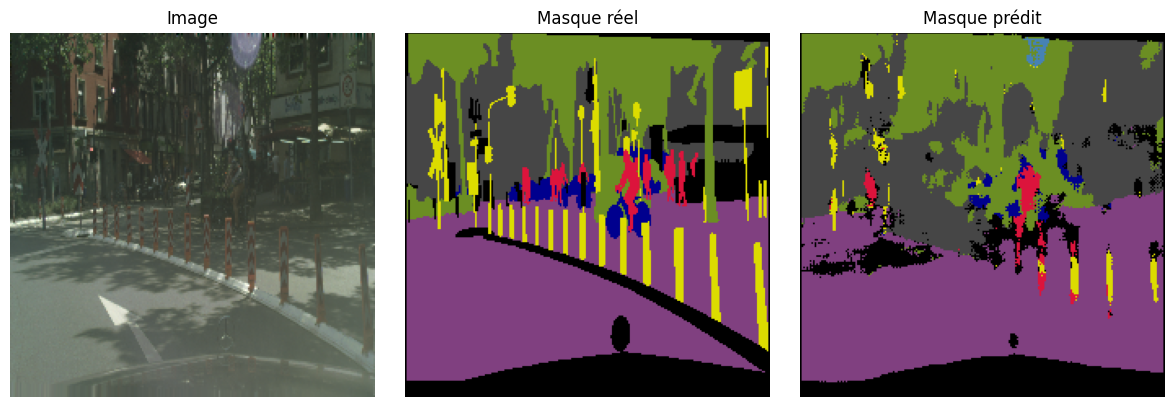

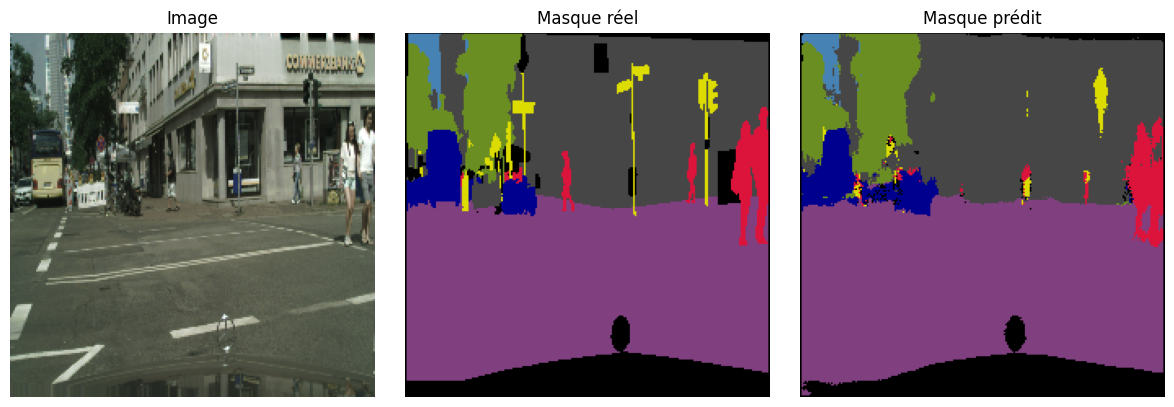

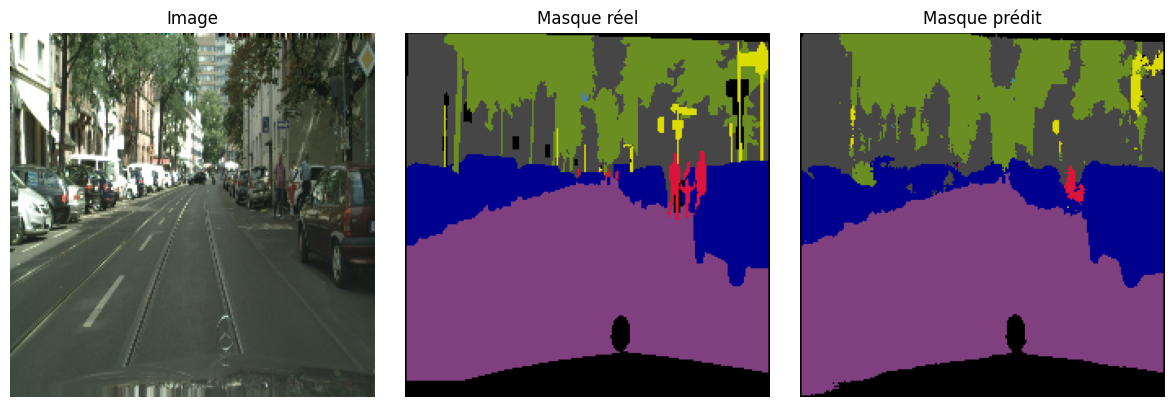

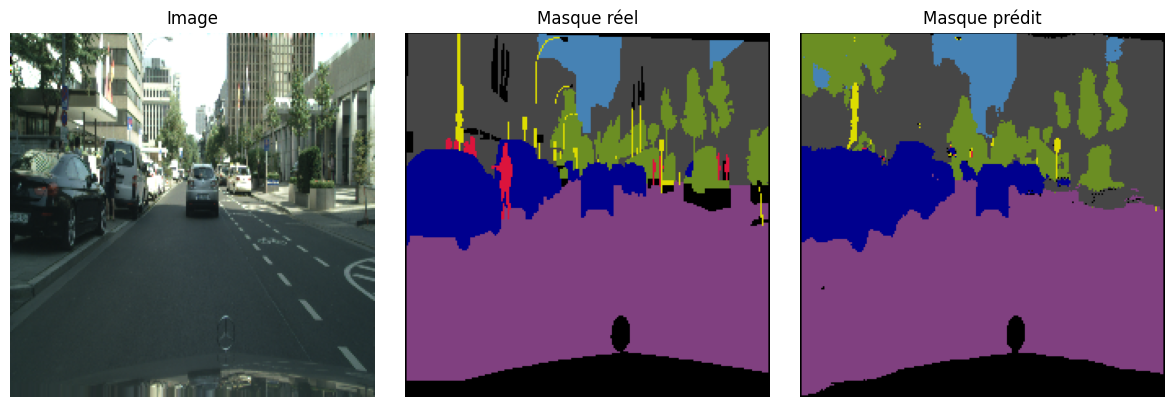

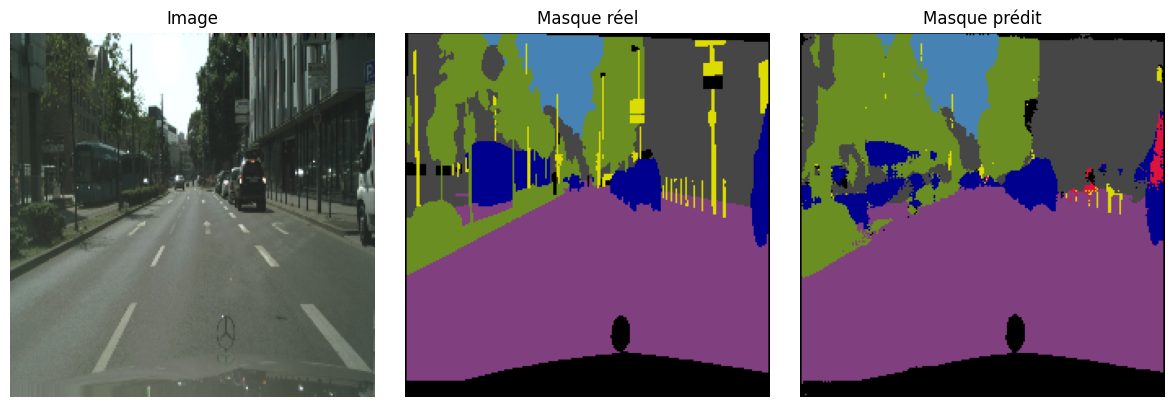

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions(model, dataset, id_to_color, num_samples=3):
    """
    Affiche quelques prédictions du modèle U-Net sur un dataset

    Args:
        model: modèle entraîné (ex: VGG16-UNet)
        dataset: un dataset tf.data contenant (image, mask)
        id_to_color: tableau (num_classes, 3) pour la couleur par classe
        num_samples: nombre d'exemples à afficher
    """
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = tf.argmax(preds, axis=-1).numpy()       # (batch, H, W)

        for i in range(num_samples):
            image = images[i].numpy()
            true_mask = masks[i].numpy()
            pred_mask = preds[i]

            # Colorisation
            true_mask_rgb = id_to_color[true_mask]
            pred_mask_rgb = id_to_color[pred_mask]

            # Affichage
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title("Masque réel")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title("Masque prédit")
            plt.axis("off")

            plt.tight_layout()
            plt.show()
display_predictions(model, val_dataset, group_colors, num_samples=5)

In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")  # Pour accéder aux fichiers personnalisés

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from losses_and_metrics import dice_metric, total_loss, mean_iou

# 📁 Paramètres
MODEL_PATH = "/content/drive/MyDrive/unet_vgg16_best_V2.h5"
NUM_CLASSES = 8
CLASS_NAMES = [
    "Flat", "Human", "Vehicle", "Construction",
    "Object", "Nature", "Sky", "Void"
]

# 📦 Chargement du modèle
model = load_model(
    MODEL_PATH,
    custom_objects={
        "dice_metric": dice_metric,
        "total_loss": total_loss,
        "mean_iou": mean_iou
    }
)

# 📊 Initialisation du compteur global
total_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

# 🔁 Parcourir les images de validation
for x_batch, _ in val_dataset:
    y_pred = model.predict(x_batch)
    y_pred_labels = np.argmax(y_pred, axis=-1)  # (batch_size, H, W)

    for pred_mask in y_pred_labels:
        class_counts = np.bincount(pred_mask.flatten(), minlength=NUM_CLASSES)
        total_counts += class_counts

# ✅ Affichage des résultats
total_pixels = np.sum(total_counts)
print("🎯 Distribution des classes détectées :\n")
for class_id, count in enumerate(total_counts):
    percentage = (count / total_pixels) * 100
    print(f"Classe {class_id:1d} - {CLASS_NAMES[class_id]:<13}: {count:8d} pixels ({percentage:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━